## Временные ряды
### Описание
Вы получаете excel, который вполне реально мог передать вам заказчик. Важно скачать его на ваш компьютер именно в формате xlsx и обрабатывать через excel, а не гугл таблицы.
Файл составлялся вручную, в нем есть и ошибки ручного ввода, и ошибки типичные для временных рядов, и проблемы оформления файла. Ваша задача - восстановить аккуратный согласованный датафрейм, по максимуму исправить ошибки в данных. В переданном файле ровно 3 листа содержащих ряды для работы, не все из них видны при открытии.
После восстановления вы обнаружите многомерный временной ряд погоды для нескольких городов. Ваша задача - обучить модели предсказывать температуру на 1 неделю вперед (многошаговый прогноз).  Размер окна из которого создаются признаки выбирается вами. 
Рекомендуется хронологическое разделение на train-val-test.
Допускается обучение отдельных моделей для каждого города или общей модели, работающей с любым городом.

Дата выдачи: 20.04.2026
Оценка на 5: 11.05.2026
Оценка на 4: 18.05.2026
Оценка на 3: 25.05.2026
### Задачи
- С помощью библиотек (openpyxl, pandas) получить доступ ко всем листам Excel-файла.
- Очистить и унифицировать данные: привести к единому временному индексу, обработать пропуски и выбросы.
- Провести анализ временного ряда: визуализация, проверка стационарности, декомпозиция на тренд, сезонность и остатки, спектральный анализ.
- Извлечь из временного ряда признаки, полезные для прогнозирования.
- Построить дерево решений, случайный лес и бустинг. Подобрать гиперпараметры через optuna. Использовать рекурсивную стратегию и стратегию создания модели на каждый из горизонтов. Сравнить результаты.
- Оценить качество прогноза на тестовом отрезке с использованием метрик WAPE, MAE, MAPE, directional accuracy, directional r2.
### Ожидаемый результат
Jupyter Notebook с полным пайплайном: от парсинга Excel до прогноза и анализа остатков модели. Если часть работы проделана методами Excel, скрины подтверждающие этапы работы.
Критерии оценивания (100 баллов)
- Успешное извлечение данных из всех листов Excel — до 20 баллов
- Качество очистки и обработки временного ряда — до 20 баллов
- Глубина анализа (декомпозиция, стационарность и т.д.) — до 15 баллов
- Feature engineering — до 15 баллов
- Корректность построения и валидации моделей — до 10 баллов
- Интерпретация результатов и выбор метрик — до 10 баллов
- Оформление и воспроизводимость — до 10 баллов


## 1. Обработка exel

Нажав на любой лист в exel, я смог найти скрытые листы. На каждом листе есть данные о погоде в разных городах. Пустые листы были проверены на реальную пустоту через рецензирование -> статистика книги -> листы.


Пример:
![../data/screenshots/пустой_лист_1.png](../data/screenshots/пустой_лист_1.png)

Соответственно, были удалены пустые листы, а данные из видимых листов были сохранены в виде отдельных датафреймов. Датафреймы были объединены в один с помощью функции pd.concat().

На одном из листов было будто данных нет, но на самом деле они там были, просто цвет шрифта был белым. Я выделил все ячейки и изменил цвет шрифта на черный, после чего данные стали видимыми

In [2]:
import pandas as pd
import numpy as np

all_sheets = pd.read_excel('../data/have_fun.xlsx', sheet_name=None)


def fix_encoding(text):
    """Пытается восстановить кириллицу из текста, который был неправильно декодирован как latin1."""
    if isinstance(text, str):
        try:
            return text.encode('latin1').decode('cp1251')
        except (UnicodeEncodeError, UnicodeDecodeError):
            return text
    return text


cleaned_data = {}

for sheet_name, df in all_sheets.items():
    fixed_sheet_name = fix_encoding(sheet_name)
    df.columns = [fix_encoding(col) for col in df.columns]
    df_cleaned = df.map(fix_encoding)
    
    cleaned_data[fixed_sheet_name] = df_cleaned
    print(f"Лист '{fixed_sheet_name}' обработан.")


example_sheet = 'Лист2_строковые_NaN_выбросы'
if example_sheet in cleaned_data:
    print(f"\nПервые 5 строк листа {example_sheet}:")
    print(cleaned_data[example_sheet].head())

Лист 'Лист1' обработан.
Лист 'Лист2_строковые_NaN_выбросы' обработан.
Лист 'Лист3_смешанные_типы' обработан.

Первые 5 строк листа Лист2_строковые_NaN_выбросы:
  temperature_2m  relative_humidity_2m  ... Unnamed: 19  Unnamed: 20
0           -6.5                  92.0  ...         NaN          NaN
1           -6.8                  92.0  ...         NaN          NaN
2           -6.8                  92.0  ...         NaN          NaN
3           -5.8                  93.0  ...         NaN          NaN
4      79.276929                  93.0  ...         NaN          NaN

[5 rows x 21 columns]


In [37]:
import chardet

with open('../data/have_fun.xlsx', 'rb') as f:
    result = chardet.detect(f.read(10000))
    print(result['encoding'])

None


Проверели через chardet, чтобы понять в какой кодировке сохранен файл. В итоге это не помогло, данные биты не из за неверной кодировки.

### Сохраняем данные в эксель после обработки, чтобы визауально проверить результат

In [38]:
with pd.ExcelWriter('../data/have_fun_clean.xlsx', engine='openpyxl') as f:

    for sheet_name, df in cleaned_data.items():
        df.to_excel(f, sheet_name=sheet_name, index=False)
    


KeyboardInterrupt: 

## 2. Обработка данных:


In [3]:
List_1_name, df_1 = list(cleaned_data.items())[0]
List_2_name, df_2 = list(cleaned_data.items())[1]
List_3_name, df_3 = list(cleaned_data.items())[2]
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

In [4]:
df.head()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,3.8,82.0,0.0,0.0,0.0,3,19.1,1010.000000,2020-01-31 02:00:00,Геленджик,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-3.0,70.0,0.0,0.0,0.0,3,24.0,981.900024,2025-02-28 09:00:00,Благовещенск,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-1.3,86.0,0.0,0.0,0.0,2,8.8,1021.200012,2022-01-03 02:00:00,Геленджик,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,19.299999,49.0,0.0,0.0,0.0,0,22.799999,1016.200012,2020-09-17 06:00:00,Геленджик,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9.6,89.0,0.0,0.0,0.0,0,8.8,1024.400024,2025-04-16 05:00:00,Геленджик,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Удалим мусор:

In [5]:
df.drop(columns=['Unnamed: 10','Unnamed: 11','Unnamed: 12','Unnamed: 13','Unnamed: 14','Unnamed: 15','Unnamed: 16','Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19','Unnamed: 20'], inplace=True)

In [6]:
df.describe()

,relative_humidity_2m,rain,snowfall,surface_pressure,ds
count,370677.000000,370652.000000,370652.000000,370651.000000,370650
mean,73.999334,0.093143,0.008089,1006.868927,2022-07-02 11:03:45.149332
min,9.000000,0.000000,0.000000,800.185777,2019-01-01 00:00:00
25%,63.000000,0.000000,0.000000,998.000000,2020-10-01 02:00:00
50%,78.000000,0.000000,0.000000,1009.099976,2022-07-02 17:00:00
75%,89.000000,0.000000,0.000000,1016.099976,2024-04-01 15:45:00
max,100.000000,27.100000,4.620000,1199.037397,2025-12-31 23:00:00
std,18.079149,0.473087,0.064195,13.575846,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373136 entries, 0 to 373135
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        368122 non-null  object        
 1   relative_humidity_2m  370677 non-null  float64       
 2   precipitation         368497 non-null  object        
 3   rain                  370652 non-null  float64       
 4   snowfall              370652 non-null  float64       
 5   weathercode           370651 non-null  object        
 6   wind_speed_10m        369050 non-null  object        
 7   surface_pressure      370651 non-null  float64       
 8   ds                    370650 non-null  datetime64[us]
 9   city                  370648 non-null  str           
dtypes: datetime64[us](1), float64(4), object(4), str(1)
memory usage: 28.5+ MB


In [8]:
for col, value in df.isna().sum().items():
    print(f"Процент пропущенных значений в столбце '{col}': {value / len(df) * 100:.2f}%")

Процент пропущенных значений в столбце 'temperature_2m': 1.34%
Процент пропущенных значений в столбце 'relative_humidity_2m': 0.66%
Процент пропущенных значений в столбце 'precipitation': 1.24%
Процент пропущенных значений в столбце 'rain': 0.67%
Процент пропущенных значений в столбце 'snowfall': 0.67%
Процент пропущенных значений в столбце 'weathercode': 0.67%
Процент пропущенных значений в столбце 'wind_speed_10m': 1.10%
Процент пропущенных значений в столбце 'surface_pressure': 0.67%
Процент пропущенных значений в столбце 'ds': 0.67%
Процент пропущенных значений в столбце 'city': 0.67%


### Найдем странные значения:

In [9]:
def find_strange_values(column:str,df:pd.DataFrame=df):    
    strange_values = set(i for i in df[column] if isinstance(i, str))
    print(f"Странные значения в столбце '{column}': {strange_values}")
    d={}
    for i in strange_values:
        d[i] = d.get(i, 0) + df[column].tolist().count(i)
    print(f"Количество странных значений в столбце '{column}': {d}")
    return strange_values

strange_values = find_strange_values('temperature_2m')
print('-' * 50)
strange_values = find_strange_values('precipitation')
print('-' * 50)
strange_values = find_strange_values('wind_speed_10m')
print('-' * 50)
strange_values = find_strange_values('weathercode')

Странные значения в столбце 'temperature_2m': {'---', '?', 'холодно', 'жарко', 'нет данных', 'NAN', 'нормально'}
Количество странных значений в столбце 'temperature_2m': {'---': 393, '?': 117, 'холодно': 251, 'жарко': 258, 'нет данных': 138, 'NAN': 364, 'нормально': 244}
--------------------------------------------------
Странные значения в столбце 'precipitation': {'---', 'ливень', '?', 'сухо', 'нет данных', 'морось', 'NAN'}
Количество странных значений в столбце 'precipitation': {'---': 126, 'ливень': 260, '?': 124, 'сухо': 221, 'нет данных': 160, 'морось': 247, 'NAN': 383}
--------------------------------------------------
Странные значения в столбце 'wind_speed_10m': {'---', 'шторм', '?', 'туман', 'нет данных', 'гроза', 'ветрено', 'NAN', 'тихо'}
Количество странных значений в столбце 'wind_speed_10m': {'---': 69, 'шторм': 254, '?': 51, 'туман': 245, 'нет данных': 77, 'гроза': 246, 'ветрено': 260, 'NAN': 63, 'тихо': 222}
--------------------------------------------------
Странные зн

### Странные значения поменяем на похожие на правду (в последствии на графиках это сделает нам расческу, поэтому лучше поменять такое на nan и сделать интерполяцию), совсем мусорные удалим.

In [10]:
temp_map = {'холодно': 5, 'нормально': 20, 'жарко': 30}
wind_map = {'тихо': 0, 'ветрено': 7, 'шторм': 20}
precip_map = {'сухо': 0, 'морось': 0.5, 'ливень': 10}
weather_fix_map = {
    'солнечно': 0,
    'пасмурно': 3,
    'дождь': 61,
    'снег': 71
}
# df['temperature_2m'] = df['temperature_2m'].replace(temp_map)
# df['wind_speed_10m'] = df['wind_speed_10m'].replace(wind_map)
# df_features['precipitation'] = df_features['precipitation'].replace(precip_map)
df['weathercode'] = df['weathercode'].replace(weather_fix_map)
garbage = ['?', 'нет данных', 'NAN', '---'] + list(temp_map.keys()) + list(wind_map.keys()) + list(precip_map.keys())

cols_to_fix = ['temperature_2m', 'precipitation', 'wind_speed_10m', 'weathercode']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col].replace(garbage, np.nan), errors='coerce')



### Отсортируем по дате и приведем дату к индексу

In [11]:
df.set_index('ds',inplace=True)
df.sort_index(inplace=True)
df.head(120)

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city
ds,,,,,,,,,
2019-01-01 00:00:00,4.500000,94.0,0.3,0.3,0.0,51.0,5.500000,1023.200012,Геленджик
2019-01-01 00:00:00,-13.700000,56.0,0.0,0.0,0.0,3.0,12.600000,1008.700012,Благовещенск
2019-01-01 00:00:00,-13.400000,58.0,0.0,0.0,0.0,0.0,5.200000,1025.500000,Находка
2019-01-01 00:00:00,4.600000,89.0,0.2,0.2,0.0,51.0,8.000000,1024.699951,Сочи
2019-01-01 00:00:00,-1.800000,85.0,0.0,0.0,0.0,3.0,23.500000,1015.200012,Санкт-Петербург
...,...,...,...,...,...,...,...,...,...
2019-01-01 19:00:00,0.300000,89.0,0.0,0.0,0.0,3.0,21.200001,986.299988,Санкт-Петербург
2019-01-01 19:00:00,-10.300000,43.0,0.0,0.0,0.0,0.0,6.200000,1019.700012,Находка
2019-01-01 19:00:00,-2.800000,91.0,0.0,0.0,0.0,3.0,27.799999,985.299988,Москва


In [12]:
cities = df['city'].unique()
print("Уникальные города в данных:", cities)

Уникальные города в данных: <StringArray>
[      'Геленджик',    'Благовещенск',         'Находка',            'Сочи',
 'Санкт-Петербург',          'Москва',           'Мосва',    'БЛАГОВЕЩЕНСК',
   'Благовещенскк',     'Благовещенс',        'Геленджи',    'благовещенск',
      'Геленджикк',       'геленджик',       'ГЕЛЕНДЖИК',               nan,
            'Сычи',             'Счи',             'Соч']
Length: 19, dtype: str


### Чистим города от мусора и приводим их к нормальным названиям

In [13]:
df['city'] = df['city'].str.strip().str.capitalize()

corrections = {
    'Геленджикк': 'Геленджик',
    'Геленджи': 'Геленджик',
    'Мосва': 'Москва',
    'Благовещенскк': 'Благовещенск',
    'Благовещенс': 'Благовещенск',
    'Сычи': 'Сочи',
    'Счи': 'Сочи',
    'Соч': 'Сочи'
}

df['city'] = df['city'].replace(corrections)
df['city'] = df['city'].str.strip()
print(df['city'].unique())

<StringArray>
[      'Геленджик',    'Благовещенск',         'Находка',            'Сочи',
 'Санкт-петербург',          'Москва',               nan]
Length: 7, dtype: str


### Оказывается Находка - это город))

In [14]:
nahodka = df[df['city'] == 'Находка']
print(nahodka)

                     temperature_2m  ...     city
ds                                   ...         
2019-01-01 00:00:00           -13.4  ...  Находка
2019-01-01 01:00:00           -13.1  ...  Находка
2019-01-01 02:00:00           -13.5  ...  Находка
2019-01-01 03:00:00           -13.9  ...  Находка
2019-01-01 04:00:00           -14.9  ...  Находка
...                             ...  ...      ...
2025-12-31 18:00:00           -14.9  ...  Находка
2025-12-31 19:00:00           -15.3  ...  Находка
2025-12-31 20:00:00           -15.6  ...  Находка
2025-12-31 21:00:00           -15.4  ...  Находка
2025-12-31 22:00:00           -16.0  ...  Находка

[61357 rows x 9 columns]


In [15]:
nan_city = df[df['city'].isna()]
print(nan_city)


                     temperature_2m  ...  city
ds                                   ...      
2021-12-02 21:00:00       -1.500000  ...   NaN
2021-12-02 22:00:00       -0.900000  ...   NaN
2025-12-31 23:00:00      -16.700001  ...   NaN
NaT                             NaN  ...   NaN
NaT                             NaN  ...   NaN
...                             ...  ...   ...
NaT                             NaN  ...   NaN
NaT                             NaN  ...   NaN
NaT                             NaN  ...   NaN
NaT                             NaN  ...   NaN
NaT                             NaN  ...   NaN

[2488 rows x 9 columns]


### Удаляем строки со всемими пропусками и удаляем строки с пропусками в городе

In [16]:
df.dropna(inplace=True,how='all')
df.dropna(subset=['city'], inplace=True)
print(df.isna().sum())

temperature_2m          4325
relative_humidity_2m       5
precipitation           3705
rain                       0
snowfall                   0
weathercode                0
wind_speed_10m          3089
surface_pressure           0
city                       0
dtype: int64


### После отчистки видим, что числовые данные стали числовыми:

In [17]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 370648 entries, 2019-01-01 00:00:00 to NaT
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   temperature_2m        366323 non-null  float64
 1   relative_humidity_2m  370643 non-null  float64
 2   precipitation         366943 non-null  float64
 3   rain                  370648 non-null  float64
 4   snowfall              370648 non-null  float64
 5   weathercode           370648 non-null  float64
 6   wind_speed_10m        367559 non-null  float64
 7   surface_pressure      370648 non-null  float64
 8   city                  370648 non-null  str    
dtypes: float64(8), str(1)
memory usage: 28.3 MB


In [18]:
df.describe()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
count,366323.000000,370643.000000,366943.000000,370648.000000,370648.000000,370648.000000,367559.000000,370648.000000
mean,8.725544,73.997890,1.355631,0.093144,0.008089,11.216375,12.105107,1006.869069
std,12.279806,18.079047,31.131876,0.473090,0.064195,21.451587,10.334791,13.575683
min,-49.990098,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.185777
25%,1.000000,63.000000,0.000000,0.000000,0.000000,0.000000,6.700000,998.000000
50%,10.000000,78.000000,0.000000,0.000000,0.000000,3.000000,10.500000,1009.099976
75%,17.900000,89.000000,0.000000,0.000000,0.000000,3.000000,15.600000,1016.099976
max,79.974214,100.000000,998.260221,27.100000,4.620000,75.000000,249.928074,1199.037397


#### Посмотрим корреляцию между осадками, дождем и снегом. Они должны быть связаны, так как дождь и снег - это виды осадков. Если корреляция будет высокой, это будет подтверждением того, что данные были очищены правильно.

In [19]:
correlation = df[['precipitation', 'rain', 'snowfall']].corr()
print(correlation)

               precipitation      rain  snowfall
precipitation       1.000000  0.011777  0.004788
rain                0.011777  1.000000  0.008269
snowfall            0.004788  0.008269  1.000000


#### Получили очень странные, маленькие результаты, это плохо. Кажется я смотрел глазами на данные отдеьных листов и видел там сильную корреляцию, нужно проверить

In [20]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 125124 entries, 0 to 125123
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        123249 non-null  float64       
 1   relative_humidity_2m  125124 non-null  int64         
 2   precipitation         123877 non-null  float64       
 3   rain                  125124 non-null  float64       
 4   snowfall              125124 non-null  float64       
 5   weathercode           125124 non-null  int64         
 6   wind_speed_10m        123872 non-null  float64       
 7   surface_pressure      125124 non-null  float64       
 8   ds                    125124 non-null  datetime64[us]
 9   city                  125124 non-null  str           
dtypes: datetime64[us](1), float64(6), int64(2), str(1)
memory usage: 9.5 MB


In [21]:
df_1.describe()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds
count,123249.000000,125124.000000,123877.000000,125124.000000,125124.000000,125124.000000,123872.000000,125124.000000,125124
mean,8.280130,70.459304,0.089973,0.082961,0.004956,9.552700,12.112857,1005.869312,2022-07-02 06:53:28.190275
min,-41.900002,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,969.700012,2019-01-01 00:00:00
25%,0.800000,58.000000,0.000000,0.000000,0.000000,0.000000,6.900000,995.900024,2020-09-30 18:45:00
50%,10.800000,73.000000,0.000000,0.000000,0.000000,2.000000,10.500000,1008.000000,2022-07-02 13:00:00
75%,19.000000,85.000000,0.000000,0.000000,0.000000,3.000000,15.800000,1015.099976,2024-04-01 11:00:00
max,37.799999,100.000000,18.000000,18.000000,2.240000,75.000000,56.099998,1034.699951,2025-12-31 23:00:00
std,14.185939,18.617765,0.432052,0.426297,0.047901,19.795132,7.214853,12.303462,NaN


In [22]:
correlation = df_1[['precipitation', 'rain', 'snowfall']].corr()
print(correlation)

               precipitation      rain  snowfall
precipitation       1.000000  0.987366  0.162411
rain                0.987366  1.000000  0.004051
snowfall            0.162411  0.004051  1.000000


In [23]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 125276 entries, 0 to 125275
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122142 non-null  object        
 1   relative_humidity_2m  122822 non-null  float64       
 2   precipitation         122133 non-null  object        
 3   rain                  122792 non-null  float64       
 4   snowfall              122792 non-null  float64       
 5   weathercode           122791 non-null  float64       
 6   wind_speed_10m        122442 non-null  object        
 7   surface_pressure      122791 non-null  float64       
 8   ds                    122790 non-null  datetime64[us]
 9   city                  122788 non-null  str           
 10  Unnamed: 10           0 non-null       float64       
 11  Unnamed: 11           1 non-null       str           
 12  Unnamed: 12           1 non-null       str           
 13  Unnamed: 1

In [24]:
strange_values = find_strange_values('precipitation',df_2)

Странные значения в столбце 'precipitation': {'NAN', '?', '---', 'нет данных'}
Количество странных значений в столбце 'precipitation': {'NAN': 128, '?': 124, '---': 126, 'нет данных': 160}


In [25]:
garbage = ['?', 'нет данных', 'NAN', '---']
df_2['precipitation'] = pd.to_numeric(df_2['precipitation'].replace(garbage, np.nan), errors='coerce')
df_2.drop(columns=['Unnamed: 10','Unnamed: 11','Unnamed: 12','Unnamed: 13','Unnamed: 14','Unnamed: 15','Unnamed: 16','Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19','Unnamed: 20'], inplace=True)
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 125276 entries, 0 to 125275
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122142 non-null  object        
 1   relative_humidity_2m  122822 non-null  float64       
 2   precipitation         121595 non-null  float64       
 3   rain                  122792 non-null  float64       
 4   snowfall              122792 non-null  float64       
 5   weathercode           122791 non-null  float64       
 6   wind_speed_10m        122442 non-null  object        
 7   surface_pressure      122791 non-null  float64       
 8   ds                    122790 non-null  datetime64[us]
 9   city                  122788 non-null  str           
dtypes: datetime64[us](1), float64(6), object(2), str(1)
memory usage: 9.6+ MB


In [26]:
df_2.describe()

,relative_humidity_2m,precipitation,rain,snowfall,weathercode,surface_pressure,ds
count,122822.000000,121595.000000,122792.000000,122792.000000,122791.000000,122791.000000,122790
mean,73.163578,3.864620,0.075322,0.009829,10.443892,1001.004853,2022-07-02 14:52:33.393599
min,9.000000,0.000000,0.000000,0.000000,0.000000,800.185777,2019-01-01 00:00:00
25%,59.000000,0.000000,0.000000,0.000000,0.000000,991.599976,2020-10-01 05:00:00
50%,78.000000,0.000000,0.000000,0.000000,3.000000,1001.500000,2022-07-03 02:00:00
75%,90.000000,0.000000,0.000000,0.000000,3.000000,1011.000000,2024-04-01 18:00:00
max,100.000000,998.260221,27.100000,2.590000,75.000000,1199.037397,2025-12-31 23:00:00
std,19.710642,53.990007,0.480686,0.066278,20.977507,15.319155,NaN


In [27]:
corr = df_2[['precipitation', 'rain', 'snowfall']].corr()
print(corr)

               precipitation      rain  snowfall
precipitation       1.000000  0.005593   0.00279
rain                0.005593  1.000000  -0.00391
snowfall            0.002790 -0.003910   1.00000


#### Как видно ниже, сильные выбросы на 1 метр осадков за, видимо час, сильно портит корреляцию. Удалим их и посмотрим на корреляцию снова, но уже на всех данных, а не на отдельных листах.

In [28]:
check_diff = df_2['precipitation'] - (df_2['rain'] + df_2['snowfall'])
print(check_diff.describe())
print(df_2[abs(df_2['precipitation'] - (df_2['rain'] + df_2['snowfall'])) > 10].head())

count    121565.000000
mean          3.780244
std          53.995944
min          -0.070000
25%           0.000000
50%           0.000000
75%           0.000000
max         998.260221
dtype: float64
     temperature_2m  relative_humidity_2m  ...                  ds    city
411            -3.8                  86.0  ... 2019-01-17 16:00:00  Москва
516           -13.6                  83.0  ... 2019-01-21 23:00:00  Москва
847             1.1                  95.0  ... 2019-02-04 11:00:00  Москва
936            -3.2                  86.0  ... 2019-02-08 03:00:00  Москва
1291           -9.2                  70.0  ... 2019-02-22 16:00:00  Москва

[5 rows x 10 columns]


#### Удаляем выбросы не через квартили, так как они всё обнулили (убрано из ноубука):

In [29]:
cols = ['precipitation', 'rain', 'snowfall']

# 100мм осадков - сильный ливень, все что выше - мусор
df.loc[df['precipitation'] > 100, 'precipitation'] = np.nan
df.loc[df['rain'] > 100, 'rain'] = np.nan
df.loc[df['snowfall'] > 50, 'snowfall'] = np.nan


df[cols] = df[cols].interpolate(method='linear').ffill().bfill()

new_corr = df[cols].corr()
print(new_corr)

               precipitation      rain  snowfall
precipitation       1.000000  0.973892  0.195951
rain                0.973892  1.000000  0.008269
snowfall            0.195951  0.008269  1.000000


In [30]:
def clean_climate_outliers(df):
    df.loc[df['temperature_2m'] > 55, 'temperature_2m'] = np.nan
    q1 = df['temperature_2m'].quantile(0.25)
    q3 = df['temperature_2m'].quantile(0.75)
    iqr = q3 - q1
    df.loc[(df['temperature_2m'] < q1 - 1.5*iqr) | (df['temperature_2m'] > q3 + 1.5*iqr), 'temperature_2m'] = np.nan
    df.loc[df['wind_speed_10m'] > 80, 'wind_speed_10m'] = np.nan
    df.loc[(df['surface_pressure'] < 870) | (df['surface_pressure'] > 1000), 'surface_pressure'] = np.nan
    cols_to_fix = ['temperature_2m', 'wind_speed_10m', 'surface_pressure']
    df[cols_to_fix] = df[cols_to_fix].interpolate(method='linear').ffill().bfill()

    return df

df = clean_climate_outliers(df)

In [31]:
df.describe()

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
count,370648.000000,370643.000000,370648.000000,370648.000000,370648.000000,370648.000000,370648.000000,370648.000000
mean,8.925943,73.997890,0.104713,0.093144,0.008089,11.216375,11.793635,990.533330
std,11.465642,18.079047,0.481321,0.473090,0.064195,21.451587,6.853057,8.296578
min,-24.100000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,870.049464
25%,1.200000,63.000000,0.000000,0.000000,0.000000,0.000000,6.700000,987.049988
50%,10.000000,78.000000,0.000000,0.000000,0.000000,3.000000,10.500000,991.750000
75%,17.799999,89.000000,0.000000,0.000000,0.000000,3.000000,15.500000,995.900024
max,37.799999,100.000000,27.100000,27.100000,4.620000,75.000000,56.099998,1000.000000


In [32]:
df.isna().sum()

temperature_2m          0
relative_humidity_2m    5
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
city                    0
dtype: int64

In [33]:
df['relative_humidity_2m'] = df['relative_humidity_2m'].interpolate(method='linear').ffill().bfill()
df.isna().sum()

temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
city                    0
dtype: int64

#### Удалим столбцы rain и snow, так как они являются частью осадков и могут вносить избыточную информацию, которая может ухудшать качество модели. Оставим только столбец precipitation, который уже включает в себя информацию о дожде и снеге. Это поможет упростить модель и избежать проблем с мультиколлинеарностью.

In [34]:
df.drop(columns=['rain'], inplace=True)

#### Проверим дубликаты:

In [35]:
count = df.reset_index().duplicated().sum()
print(f"Всего полных дублей: {count}")


all_duples = df[df.reset_index().duplicated(keep=False).values].sort_index()
print(all_duples.head(20))

Всего полных дублей: 866
                     temperature_2m  ...          city
ds                                   ...              
2019-01-04 12:00:00       10.800000  ...     Геленджик
2019-01-04 12:00:00       10.800000  ...     Геленджик
2019-01-09 09:00:00      -18.600000  ...  Благовещенск
2019-01-09 09:00:00      -18.600000  ...  Благовещенск
2019-01-22 01:00:00      -21.100000  ...  Благовещенск
2019-01-22 01:00:00      -21.100000  ...  Благовещенск
2019-01-27 08:00:00      -21.200001  ...  Благовещенск
2019-01-27 08:00:00      -21.200001  ...  Благовещенск
2019-01-27 22:00:00      -15.600000  ...  Благовещенск
2019-01-27 22:00:00      -15.600000  ...  Благовещенск
2019-01-28 03:00:00      -16.500000  ...  Благовещенск
2019-01-28 03:00:00      -16.500000  ...  Благовещенск
2019-01-30 17:00:00      -12.600000  ...  Благовещенск
2019-01-30 17:00:00      -12.600000  ...  Благовещенск
2019-02-03 12:00:00      -18.100000  ...  Благовещенск
2019-02-03 12:00:00      -18.100000  ...

In [36]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


In [37]:
df.isna().sum()

temperature_2m          0
relative_humidity_2m    0
precipitation           0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
city                    0
dtype: int64

#### Мигом взглянем на корреляцию между осадками и относительно влажностью:

In [38]:
corr = df[['precipitation','relative_humidity_2m']].corr()
print(corr)

                      precipitation  relative_humidity_2m
precipitation              1.000000              0.182864
relative_humidity_2m       0.182864              1.000000


### 3. Анализ временного ряда

##### Построим график временного ряда температуры:

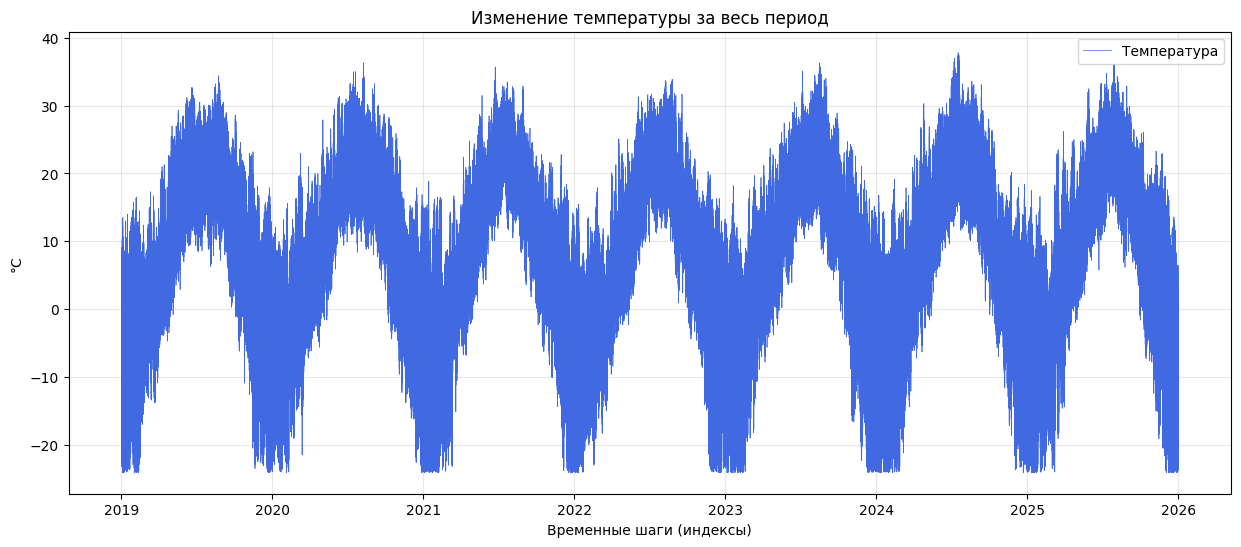

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(df['temperature_2m'], label='Температура', color='royalblue', linewidth=0.5)
plt.title('Изменение температуры за весь период')
plt.xlabel('Временные шаги (индексы)')
plt.ylabel('°C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### Построим боксплоты временного ряда по городам:

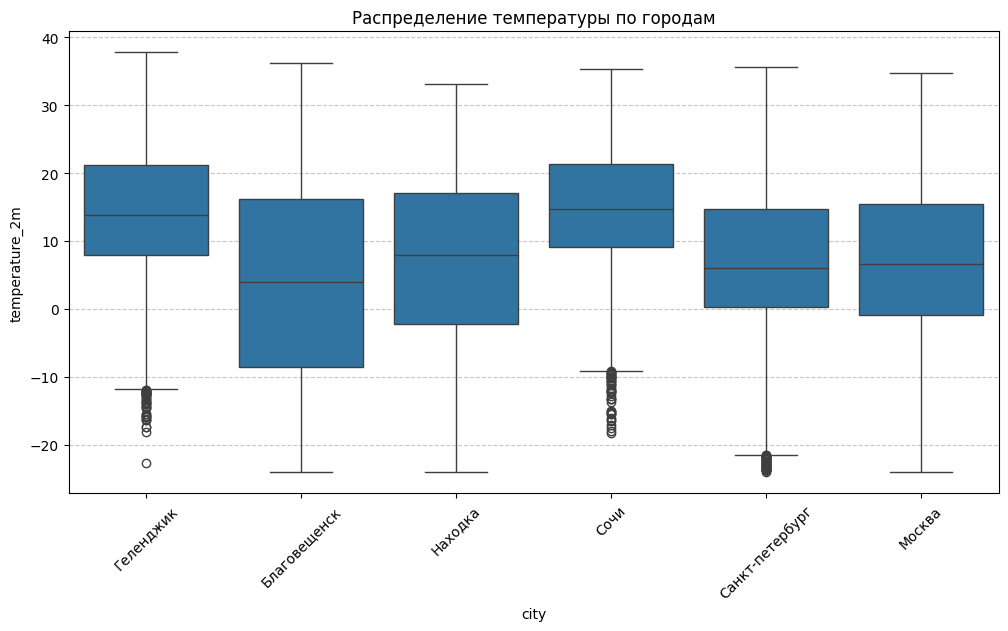

In [40]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='city', y='temperature_2m', data=df)
plt.title('Распределение температуры по городам')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

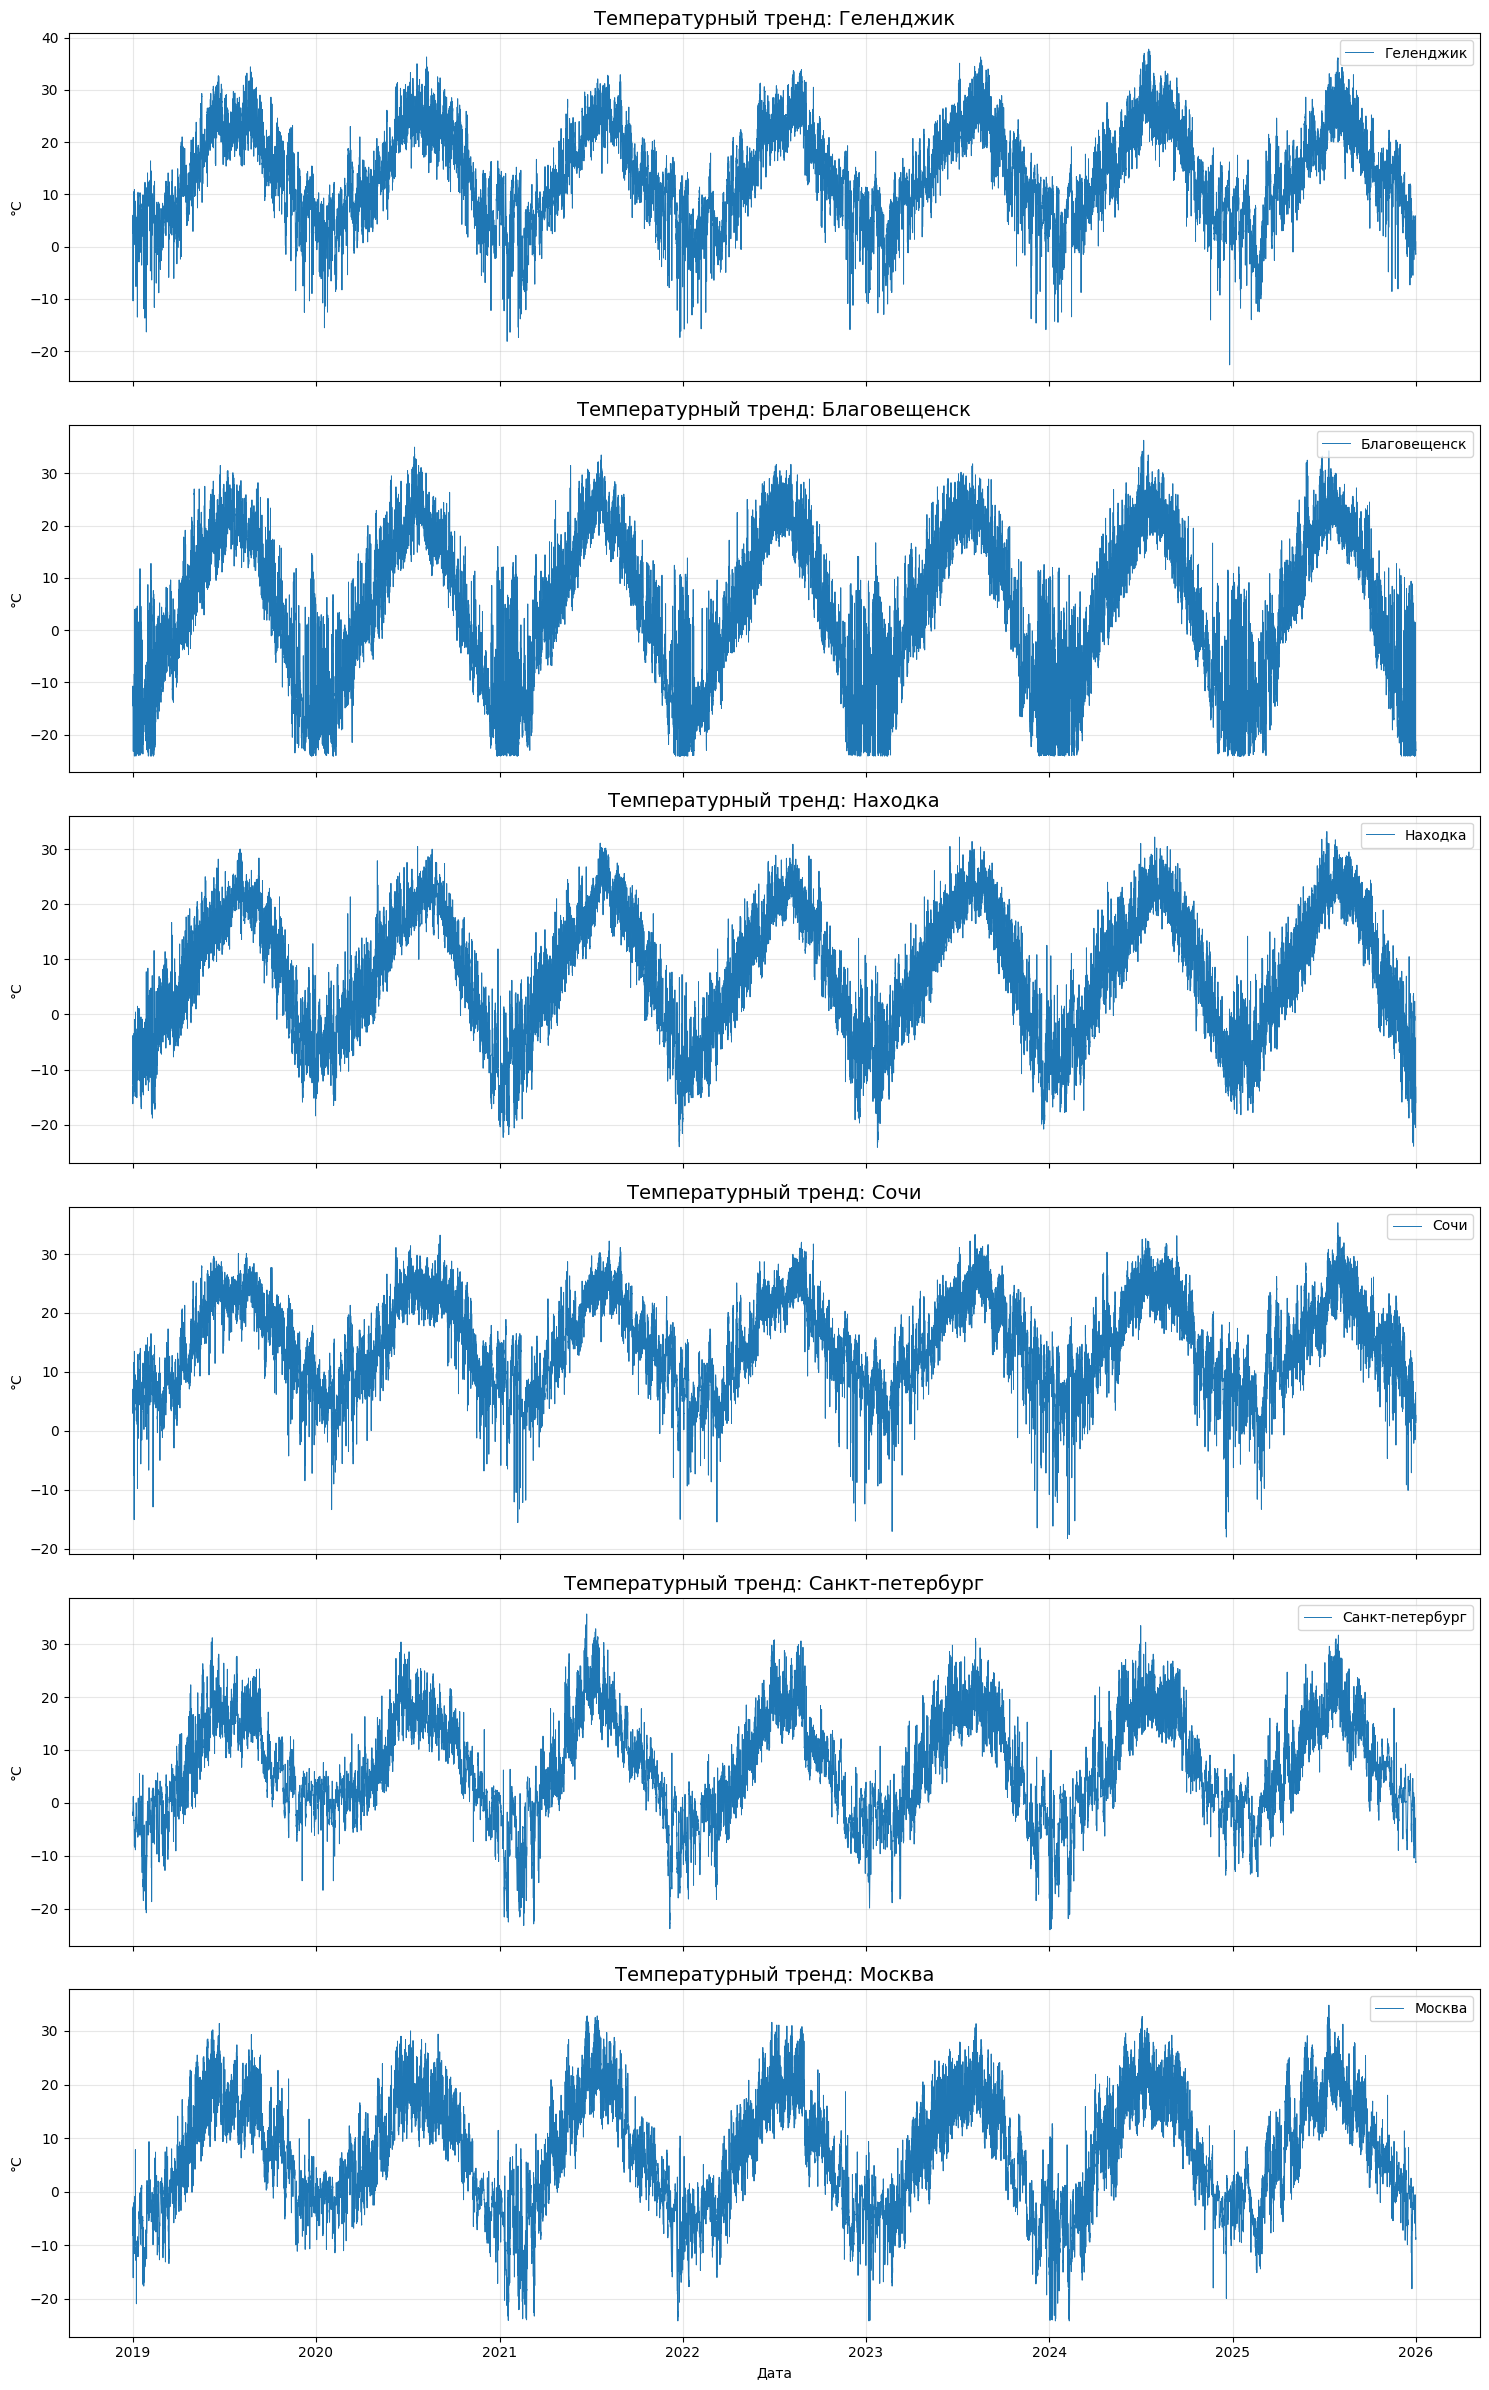

In [41]:
cities = df['city'].unique()

# Создаем большую фигуру
fig, axes = plt.subplots(len(cities), 1, figsize=(15, 4 * len(cities)), sharex=True)

for i, city in enumerate(cities):
    city_data = df[df['city'] == city]
    
    axes[i].plot(city_data.index, city_data['temperature_2m'], label=city, linewidth=0.7)
    axes[i].set_title(f'Температурный тренд: {city}', fontsize=14)
    axes[i].set_ylabel('°C')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper right')

plt.xlabel('Дата')
plt.tight_layout()
plt.show()

#### Проверим стационарность ряда с помощью скользящего окна: 

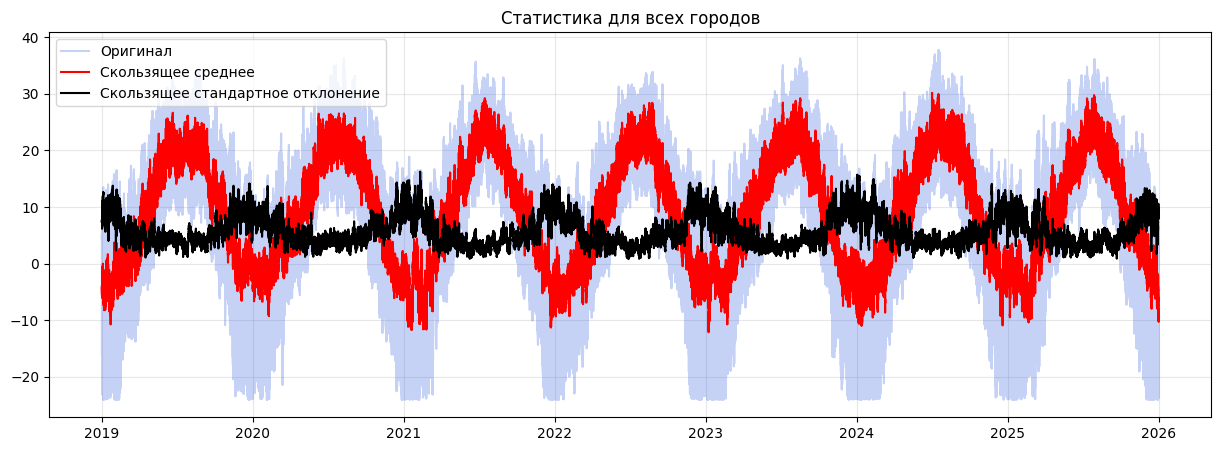

In [42]:
def plot_rolling_stats(series, window=30, title=""):
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()

    plt.figure(figsize=(15, 5))
    plt.plot(series, color='royalblue', alpha=0.3, label='Оригинал')
    plt.plot(rolling_mean, color='red', label='Скользящее среднее')
    plt.plot(rolling_std, color='black', label='Скользящее стандартное отклонение')
    plt.legend(loc='best')
    plt.title(f'Статистика для {title}')
    plt.grid(True, alpha=0.3)
    plt.show()

# Проверяем для одного города (например, Сочи)
plot_rolling_stats(df['temperature_2m'], window=30, title="всех городов")

#### Вывод: Ряд не является стационарным, так как среднее и дисперсия изменяются со временем.

#### Декомпозируем ряд на тренд, сезонность и остатки:

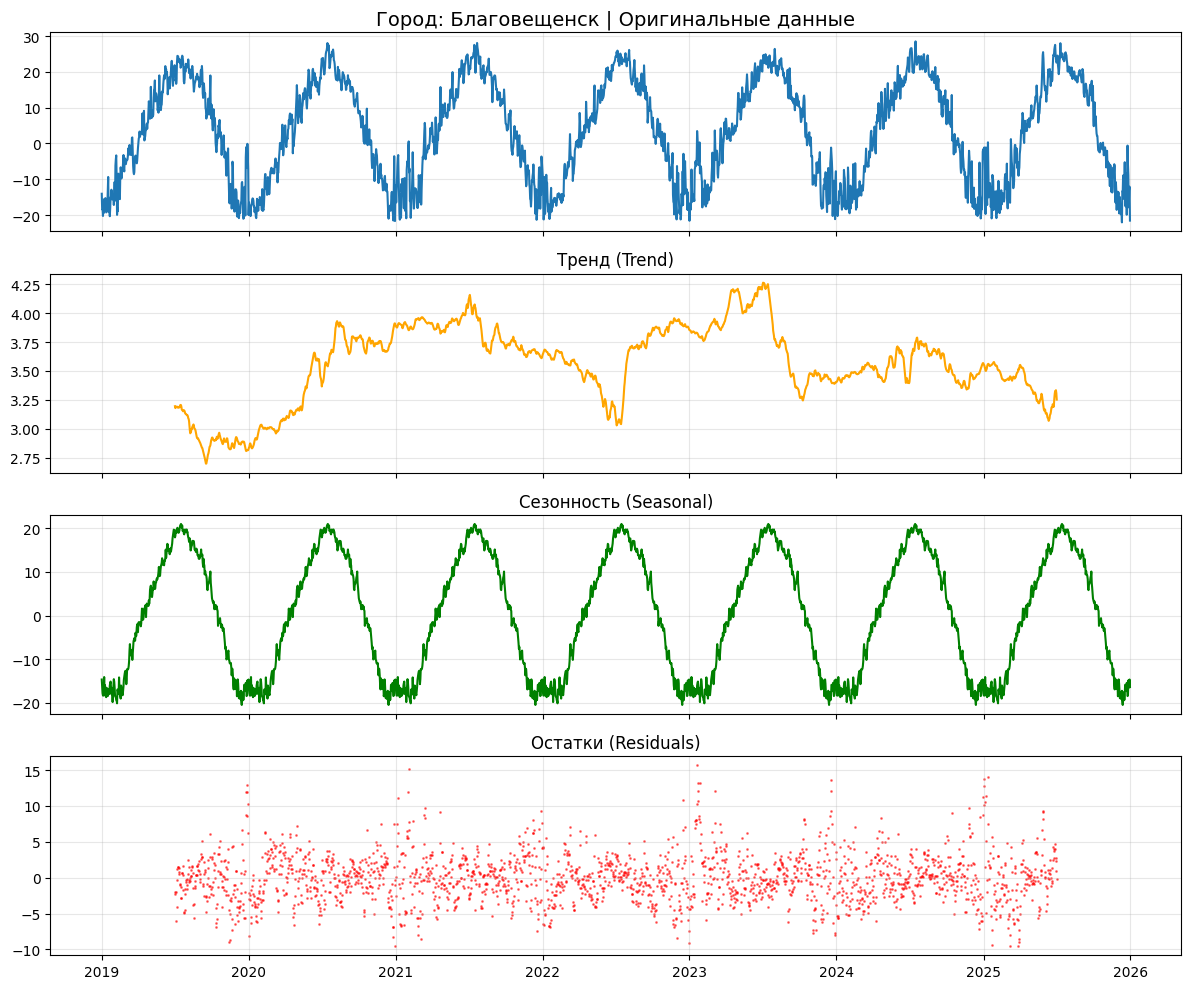

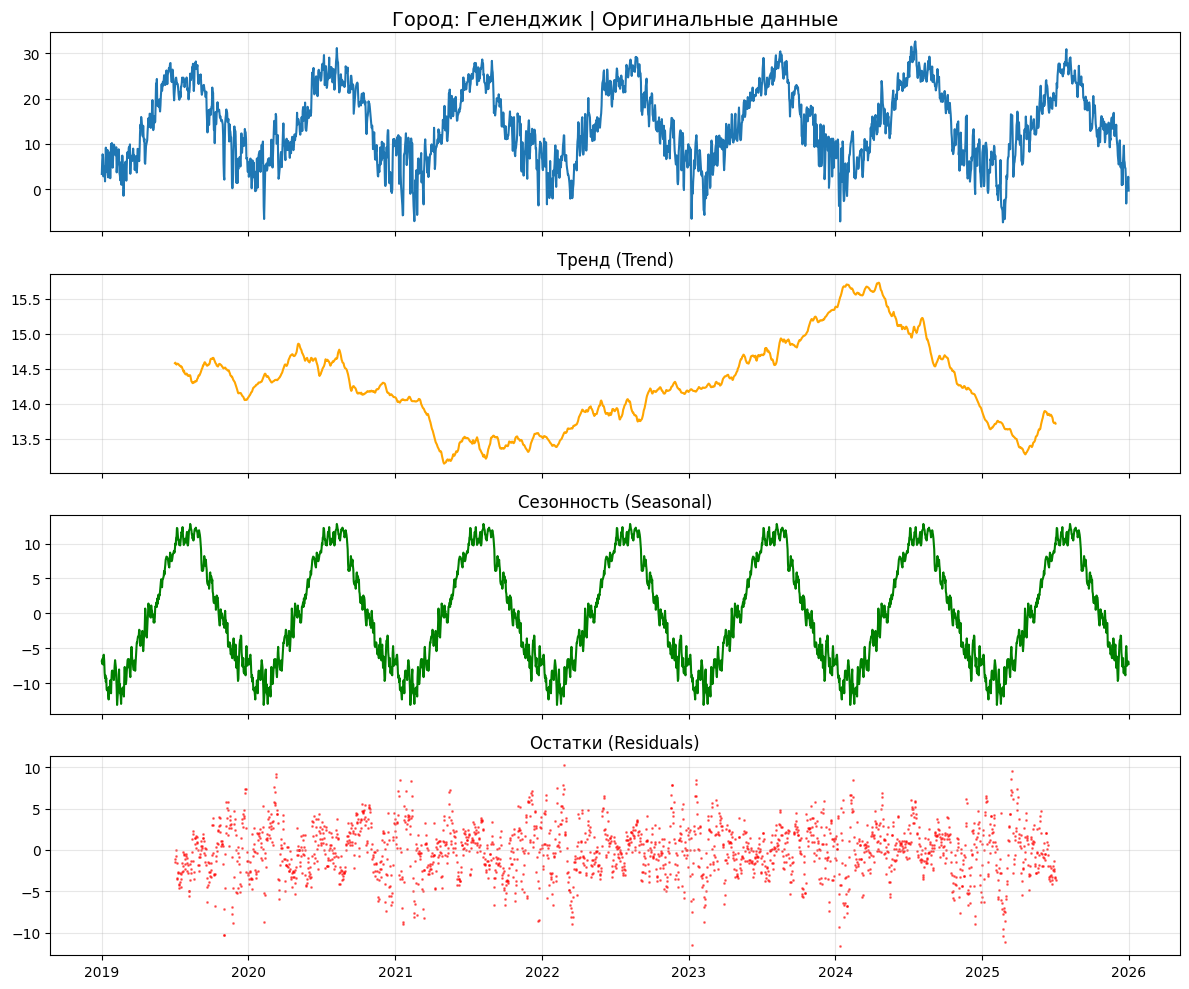

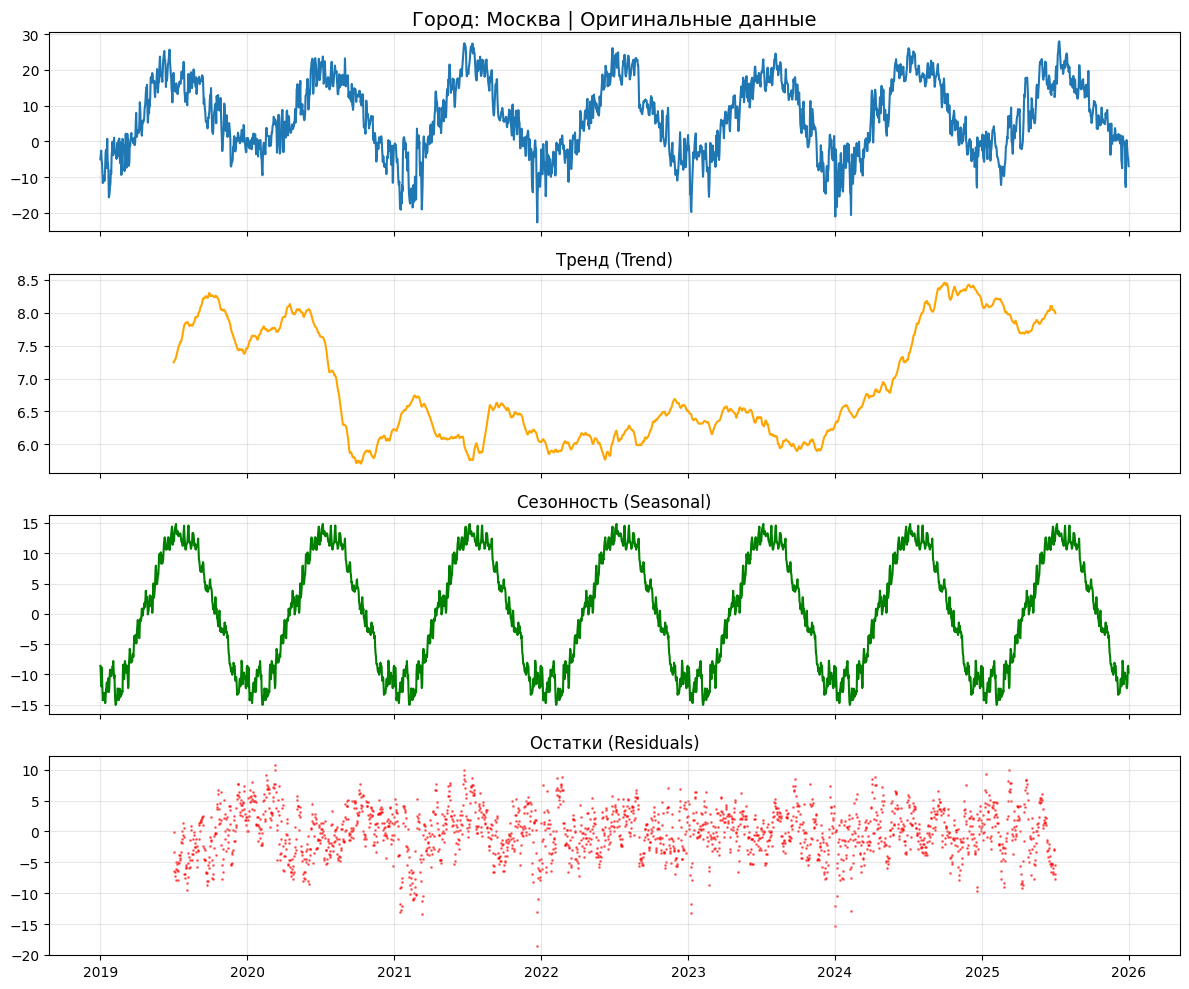

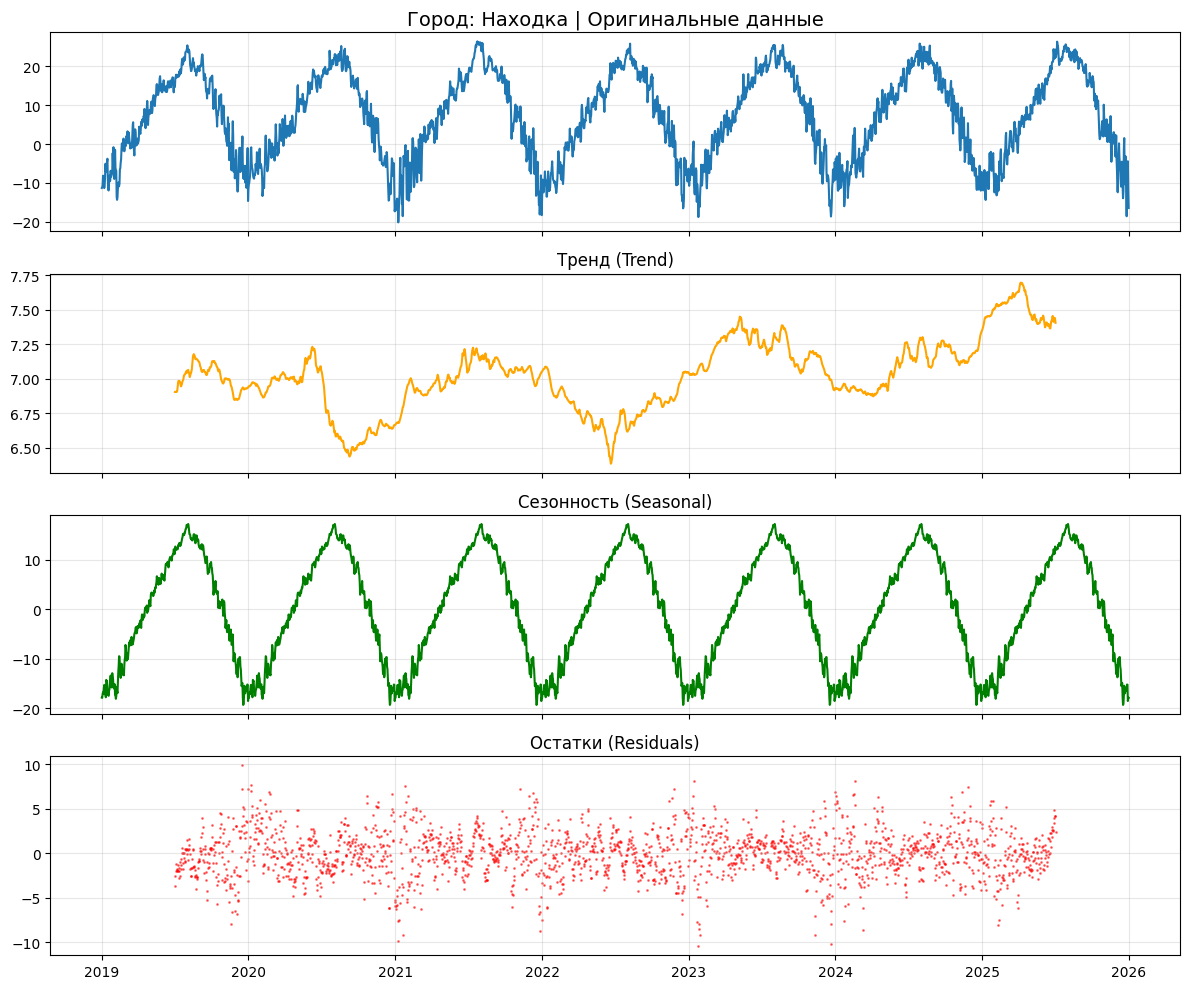

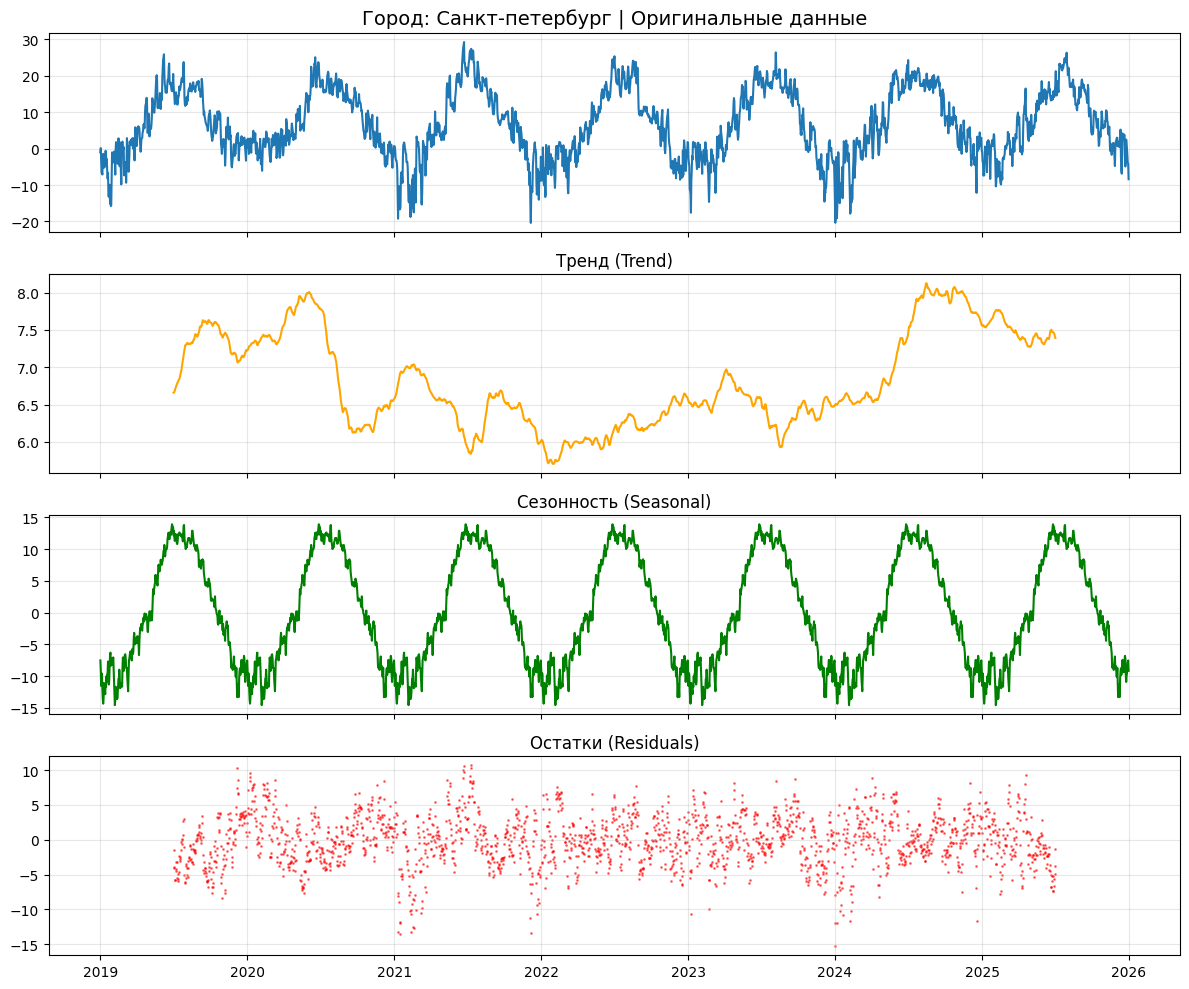

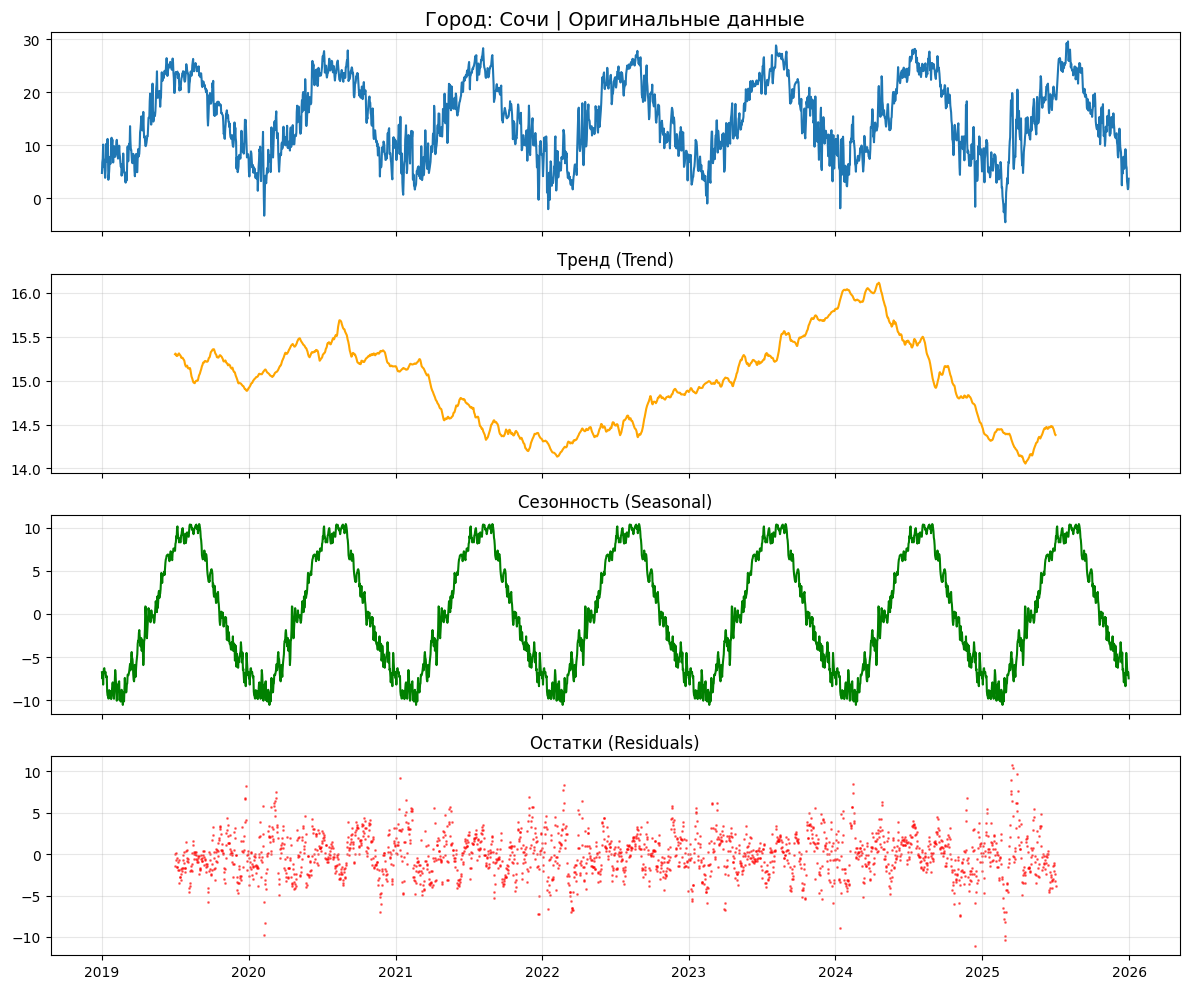

In [43]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
df_weekly = df.groupby('city')['temperature_2m'].resample('D').mean().dropna()
cities = df_weekly.index.get_level_values('city').unique()

for city in cities:
    
    # .xs позволяет удобно достать данные из MultiIndex по значению в уровне
    city_series = df_weekly.xs(city, level='city')
    if len(city_series) < 365 * 2:
        print(f"Недостаточно данных для декомпозиции города {city}")
        continue

    decompose = seasonal_decompose(city_series, model='additive', period=365)
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    axes[0].plot(decompose.observed)
    axes[0].set_title(f'Город: {city} | Оригинальные данные', fontsize=14)
    axes[1].plot(decompose.trend, color='orange')
    axes[1].set_title('Тренд (Trend)')
    axes[2].plot(decompose.seasonal, color='green')
    axes[2].set_title('Сезонность (Seasonal)')
    axes[3].scatter(decompose.resid.index, decompose.resid, color='red', s=1, alpha=0.5)
    axes[3].set_title('Остатки (Residuals)')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

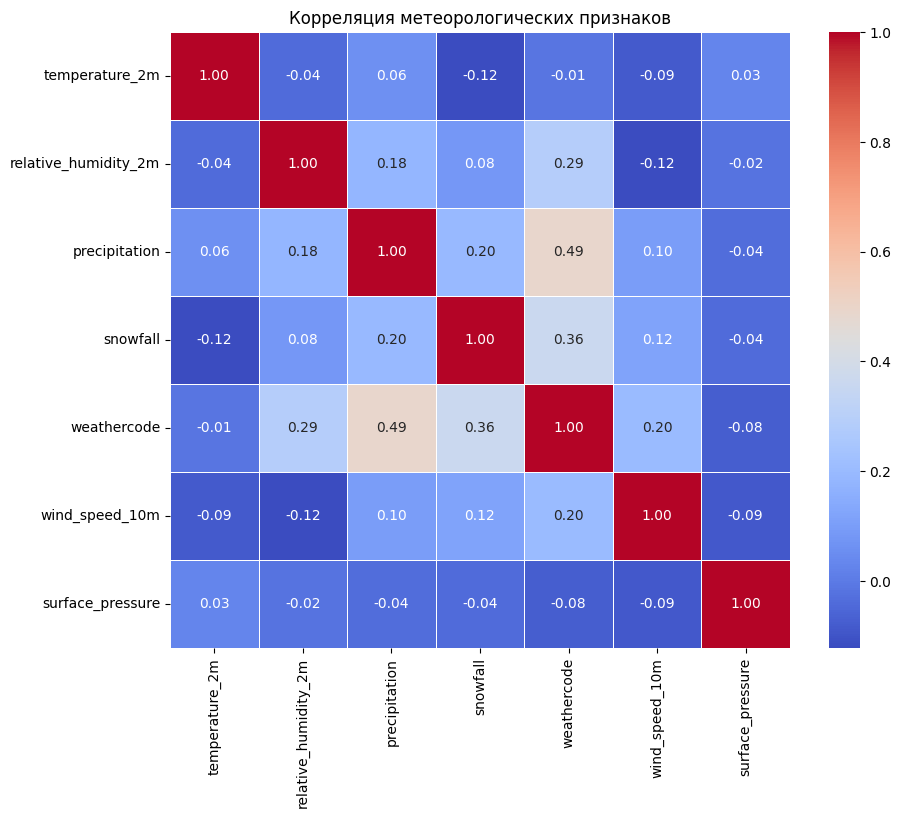

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[numeric_columns].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Корреляция метеорологических признаков')
plt.show()

#### Строим вейвлет-спектр для ряда и подтверждаем наличие сезонности 365 дней:

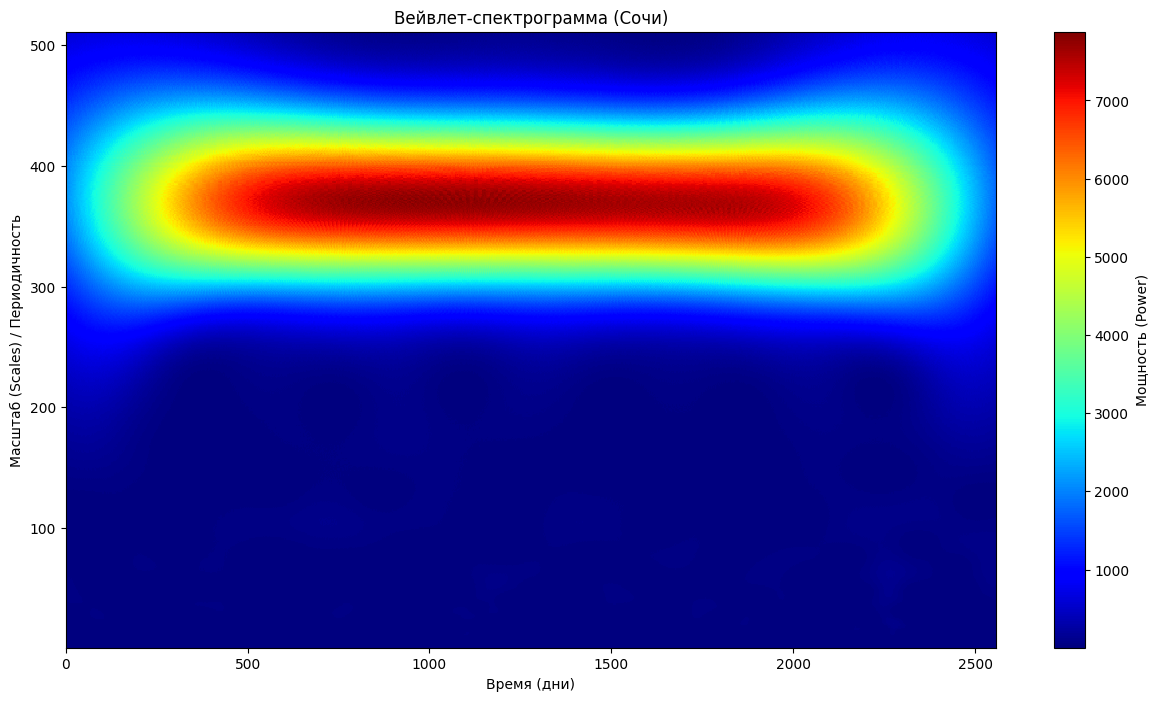

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

def plot_wavelet_spectrogram(series, title="Вейвлет-спектрограмма (Сочи)"):
    data = series.interpolate().dropna().values
    data = data - np.mean(data)
    scales = np.arange(1, 512)
    wavelet = 'cmor1.5-1.0'
    
    coefficients, frequencies = pywt.cwt(data, scales, wavelet)
    
    power = (np.abs(coefficients)) ** 2

    plt.figure(figsize=(15, 8))


    im = plt.imshow(power, extent=[0, len(data), scales[-1], scales[0]], 
                    cmap='jet', aspect='auto', interpolation='nearest')
    
    plt.colorbar(im, label='Мощность (Power)')
    plt.title(title)
    plt.ylabel('Масштаб (Scales) / Периодичность')
    plt.xlabel('Время (дни)')
    plt.gca().invert_yaxis()
    
    plt.show()

plot_wavelet_spectrogram(df_weekly['Сочи'])

#### Проверка на стационарность ряда не требуется, так как я использую модели, которые не требуют стационарности данных.

### 4. Feature engineering и подготовка данных к обучению

#### Подготовка признаков для модели (делаем это до разбиения на train-val-test, так как мои признаки используют только лаги, то есть информацию о будущем не используют, а значит не могут привести к утечке данных):

In [46]:
df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'precipitation', 'snowfall',
       'weathercode', 'wind_speed_10m', 'surface_pressure', 'city'],
      dtype='str')

#### Меняем гранулярность ряда с часов на дни:

In [47]:
df_daily = df.copy()
df_daily = df_daily.reset_index(names='date')


df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily['date_only'] = df_daily['date'].dt.date


df_daily = df_daily.groupby(['city', 'date_only']).agg(
    temp_mean=('temperature_2m', 'mean'),
    temp_min=('temperature_2m', 'min'),
    temp_max=('temperature_2m', 'max'),
    precipitation_sum=('precipitation', 'sum'),
    wind_speed_mean=('wind_speed_10m', 'mean'),
    humidity_mean=('relative_humidity_2m', 'mean'),
    pressure_mean=('surface_pressure', 'mean'),
    weathercode=('weathercode', lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0])
).reset_index()

df_daily.rename(columns={'date_only': 'ds'}, inplace=True)
df_daily['ds'] = pd.to_datetime(df_daily['ds'])
df_daily = df_daily.set_index('ds')

print(f"Данные агрегированы с часов на дни")
print(f"Новый размер датафрейма: {df_daily.shape}")
print(f"Города в данных: {df_daily['city'].unique()}")

Данные агрегированы с часов на дни
Новый размер датафрейма: (15342, 9)
Города в данных: <StringArray>
['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-петербург', 'Сочи']
Length: 6, dtype: str


In [48]:
df_daily.columns

Index(['city', 'temp_mean', 'temp_min', 'temp_max', 'precipitation_sum',
       'wind_speed_mean', 'humidity_mean', 'pressure_mean', 'weathercode'],
      dtype='str')

#### Посмотрев на частичую автокорреляцию, я сделал вывод, что лаги 1-3 помогают предсказать температуру, но в нашей задаче прогнозирования на неделю вперед, эти лаги не помогут, так как они слишком близко к целевой переменной, что вызывает утечку данных. Поэтому я решил более поздние лаги, хотя они почти не коррелируют с целевой переменной.

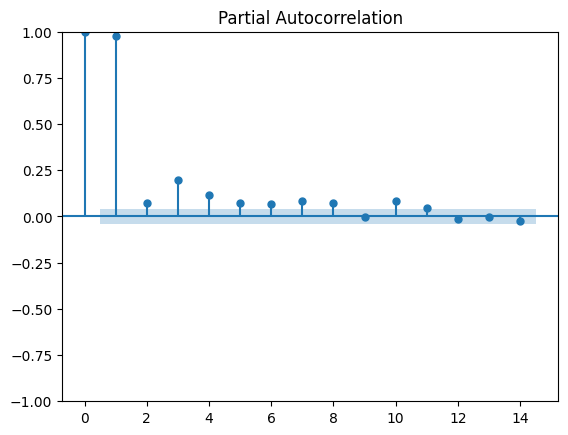

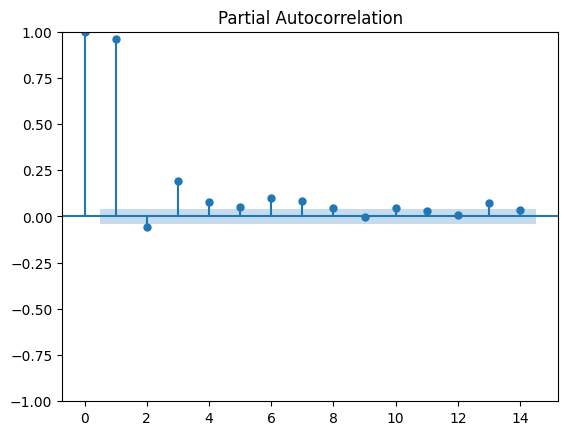

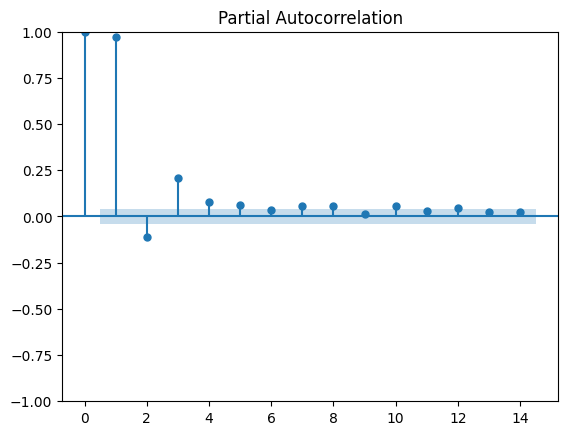

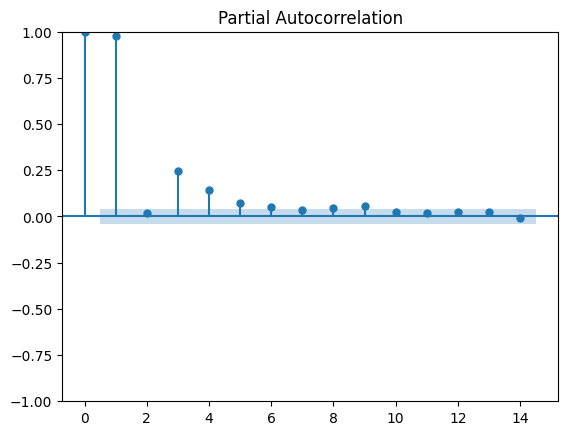

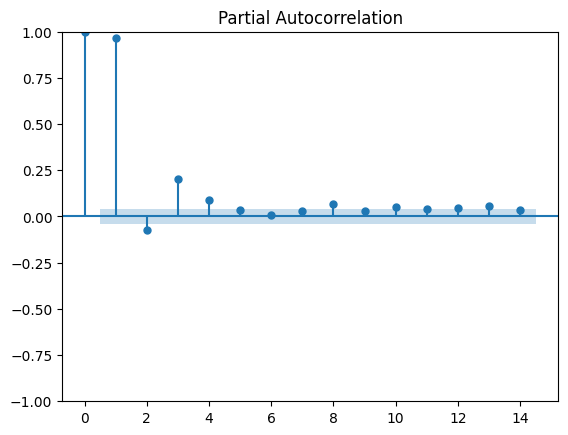

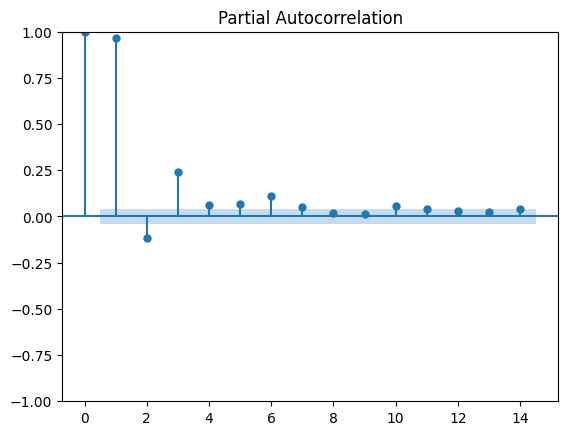

In [49]:
from statsmodels.graphics.tsaplots import plot_pacf
for city in df_daily['city'].unique():
    # 1. Фильтруем данные по городу
    data = df_daily[df_daily['city'] == city]

    # 2. Берем нужную колонку (например, температуру) и строим PACF
    # Важно: PACF строится по числам, а не по названиям городов!
    plot_pacf(data['temp_mean'], lags=14)

#### Создаем признаки для модели на основе лагов температуры, осадков и погоды:

In [50]:
import pandas as pd
import numpy as np

df_features = df_daily.copy()

df_features = df_features.reset_index()
df_features.rename(columns={'ds': 'date'}, inplace=True)
df_features = df_features.sort_values(by=['city', 'date']).reset_index(drop=True)

df_features['date'] = pd.to_datetime(df_features['date'])
df_features['day_of_year'] = df_features['date'].dt.dayofyear
df_features['month'] = df_features['date'].dt.month
df_features['day_sin'] = np.sin(2 * np.pi * df_features['day_of_year'] / 365.25)
df_features['day_cos'] = np.cos(2 * np.pi * df_features['day_of_year'] / 365.25)

df_features['target_t7'] = df_features.groupby('city')['temp_mean'].shift(-7)

df_features['temp_lag_7'] = df_features.groupby('city')['temp_mean'].shift(7)
df_features['temp_lag_10'] = df_features.groupby('city')['temp_mean'].shift(10)
df_features['temp_lag_14'] = df_features.groupby('city')['temp_mean'].shift(14)
df_features['wind_lag_7'] = df_features.groupby('city')['wind_speed_mean'].shift(7)

df_features['temp_roll_mean_7'] = df_features.groupby('city')['temp_mean'].transform(
    lambda x: x.shift(7).rolling(window=7).mean()
)
df_features['precip_roll_sum_7'] = df_features.groupby('city')['precipitation_sum'].transform(
    lambda x: x.shift(7).rolling(window=7).sum()
)

df_features = df_features.dropna().reset_index(drop=True)

print("Признаки успешно созданы!")
print(f"Размер итогового датасета: {df_features.shape}")

Признаки успешно созданы!
Размер итогового датасета: (15216, 21)


In [51]:
SPLIT_DATE = '2025-01-01'
global_train = df_features[df_features['date'] < SPLIT_DATE].copy()
global_test = df_features[df_features['date'] >= SPLIT_DATE].copy()

print(f"Размер Train: {global_train.shape[0]} строк")
print(f"Размер Test: {global_test.shape[0]} строк")

Размер Train: 13068 строк
Размер Test: 2148 строк


#### Замечание:

1. Я не совсем понял как мне скормить информацию о декомпозиции ряда в модель. Сезонность я вроде как передал, так как добавил синусоидальные признаки и модель все равно видит что происходит за 2 года.
2. Я не понял как мне добавить тренд и остатки в мою выборку.
3. Могу лишь сказать, что нашел информацию, что можно учить модель предсказывать не только температуру, но и отклонение от климатичсеской нормы, чтобы объяснить остатки.

#### Создаем фолды для кросс-валидации:

In [52]:
# здесь gap - зазор между концом обучения и началом валидации, чтобы избежать утечки данных
n_samples = len(global_train)
num_cities = df_features['city'].nunique()
TRAIN_SIZE = 365 * 2 * num_cities  
VAL_SIZE = 180 * num_cities           
GAP = 7 * num_cities                 
STEP = 180 * num_cities # сдвиг на 6 месяцев 
folds = []
train_start = 0
train_end = TRAIN_SIZE

while train_end + GAP + VAL_SIZE <= n_samples:
    
    val_start = train_end + GAP
    val_end = val_start + VAL_SIZE
    
    folds.append({
        'fold_num': len(folds) + 1,
        'train_start': train_start,
        'train_end': train_end,
        'val_start': val_start,
        'val_end': val_end
    })
    
    train_start += STEP
    train_end += STEP

print(f"Сгенерировано {len(folds)} фолдов (Sliding Window)\n")

Сгенерировано 8 фолдов (Sliding Window)



#### Обучаем дерево решений и случайный лес, бустинг обучим позже с валидацией через optuna:

In [53]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

target_col = 'target_t7'
cols_to_drop = ['date', 'city', target_col]
feature_cols = [c for c in df_features.columns if c not in cols_to_drop]
results = {
    'Decision Tree': [],
    'Random Forest': []
}

for fold in folds:
    fold_n = fold['fold_num']
    X_train = df_features.iloc[fold['train_start'] : fold['train_end']][feature_cols]
    y_train = df_features.iloc[fold['train_start'] : fold['train_end']][target_col]
    X_val = df_features.iloc[fold['val_start'] : fold['val_end']][feature_cols]
    y_val = df_features.iloc[fold['val_start'] : fold['val_end']][target_col]
    

    dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
    dt_model.fit(X_train, y_train)
    dt_preds = dt_model.predict(X_val)
    dt_mae = mean_absolute_error(y_val, dt_preds)
    results['Decision Tree'].append(dt_mae)
    
    
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_preds = rf_model.predict(X_val)
    rf_mae = mean_absolute_error(y_val, rf_preds)
    results['Random Forest'].append(rf_mae)
    print(f"Фолд {fold_n}: DT = {dt_mae:.2f} | RF = {rf_mae:.2f}")

print("\n" + "="*40)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ (Средняя MAE по всем фолдам):")
print("="*40)
for model_name, metrics in results.items():
    mean_score = np.mean(metrics)
    std_score = np.std(metrics)
    print(f"{model_name}: {mean_score:.2f} градусов (± {std_score:.2f})")

Фолд 1: DT = 4.60 | RF = 3.40
Фолд 2: DT = 4.83 | RF = 3.78
Фолд 3: DT = 4.51 | RF = 3.62
Фолд 4: DT = 3.93 | RF = 3.00
Фолд 5: DT = 2.93 | RF = 2.35
Фолд 6: DT = 3.40 | RF = 2.87
Фолд 7: DT = 3.78 | RF = 3.12
Фолд 8: DT = 4.41 | RF = 3.97

ИТОГОВЫЕ РЕЗУЛЬТАТЫ (Средняя MAE по всем фолдам):
Decision Tree: 4.05 градусов (± 0.62)
Random Forest: 3.26 градусов (± 0.50)


#### Готовим обучение бустинга с выбором гиперпараметров через optuna:

In [54]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

def objective(trial):
    """
    Эта функция будет вызываться Optuna много раз с разными параметрами
    """
    
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'early_stopping_rounds': 20
    }
    
    
    fold_maes = []
    
    
    for fold in folds:
        
        
        X_train = df_features.iloc[fold['train_start'] : fold['train_end']][feature_cols]
        y_train = df_features.iloc[fold['train_start'] : fold['train_end']][target_col]
        
        X_val = df_features.iloc[fold['val_start'] : fold['val_end']][feature_cols]
        y_val = df_features.iloc[fold['val_start'] : fold['val_end']][target_col]
        
        
        model = XGBRegressor(**param)
        
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        
        
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)
        
        fold_maes.append(mae)
    
    
    return np.mean(fold_maes)

study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=30)

print("\nОптимизация завершена!")
print(f"Лучшая ошибка MAE: {study.best_value:.4f}")
print("Лучшие параметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

c:\Users\Huawei\python_programming\Data_analysis_labs\Lab2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-05 22:20:31,712] A new study created in memory with name: no-name-9d8c4a32-d6e5-4e48-94f5-d14ed46d694c
[I 2026-05-05 22:20:34,296] Trial 0 finished with value: 3.199286262620857 and parameters: {'n_estimators': 300, 'learning_rate': 0.024519935571906237, 'max_depth': 7, 'subsample': 0.7241141892022208, 'colsample_bytree': 0.8479343613447711}. Best is trial 0 with value: 3.199286262620857.
[I 2026-05-05 22:20:35,692] Trial 1 finished with value: 3.1795709039465194 and parameters: {'n_estimators': 700, 'learning_rate': 0.018907232336247606, 'max_depth': 4, 'subsample': 0.9497489274170292, 'colsample_bytree': 0.9576050714561304}. Best is trial 1 with value: 3.1795709039465194.
[I 2026-05-05 22:2


Оптимизация завершена!
Лучшая ошибка MAE: 3.1102
Лучшие параметры:
  n_estimators: 200
  learning_rate: 0.024429677847608456
  max_depth: 4
  subsample: 0.8534160822419771
  colsample_bytree: 0.6053577738214072


#### Создаем метрики для оценки качества моделей и запускаем обучение и оценку моделей на каждом фолде:


In [55]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,r2_score

def calc_wape(y_true, y_pred):
    """Суммарная ошибка деленная на сумму абсолютных фактических значений"""
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def calc_directional_accuracy(y_true, y_pred, y_today):
    """
    Сравнивает направление изменения температуры относительно 'сегодня'.
    y_today - это фактическая температура в день прогнозирования.
    """
    actual_diff = np.sign(y_true - y_today)
    pred_diff = np.sign(y_pred - y_today)
    
    return np.mean(actual_diff == pred_diff)

def calc_r2(y_true, y_pred):
    """Коэффициент детерминации (R2)"""
    return r2_score(y_true, y_pred)

metrics_results = {
    'Decision Tree': {'MAE': [], 'MAPE': [], 'WAPE': [], 'DA': [], 'R': []},
    'Random Forest': {'MAE': [], 'MAPE': [], 'WAPE': [], 'DA': [], 'R': []},
    'XGBoost':       {'MAE': [], 'MAPE': [], 'WAPE': [], 'DA': [], 'R': []}
}


for fold in folds:
    X_train = df_features.iloc[fold['train_start'] : fold['train_end']][feature_cols]
    y_train = df_features.iloc[fold['train_start'] : fold['train_end']][target_col]
    
    X_val = df_features.iloc[fold['val_start'] : fold['val_end']][feature_cols]
    y_val = df_features.iloc[fold['val_start'] : fold['val_end']][target_col]
    
    y_today_val = df_features.iloc[fold['val_start'] : fold['val_end']]['temp_mean']
    
    models = {
        'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
        'XGBoost': XGBRegressor(**study.best_params,random_state=42, n_jobs=-1)
    }
    

    for model_name, model in models.items():

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        metrics_results[model_name]['MAE'].append(mean_absolute_error(y_val, preds))
        metrics_results[model_name]['MAPE'].append(mean_absolute_percentage_error(y_val, preds))
        metrics_results[model_name]['WAPE'].append(calc_wape(y_val, preds))
        metrics_results[model_name]['DA'].append(calc_directional_accuracy(y_val, preds, y_today_val))
        metrics_results[model_name]['R'].append(calc_r2(y_val, preds))


final_report = []

for model_name, metrics in metrics_results.items():
    final_report.append({
        'Модель': model_name,
        'MAE (°C)': np.mean(metrics['MAE']),
        'MAPE (%)': np.mean(metrics['MAPE']) * 100,
        'WAPE (%)': np.mean(metrics['WAPE']) * 100,
        'Dir. Accuracy (%)': np.mean(metrics['DA']) * 100,
        'R2': np.mean(metrics['R'])
    })

report_df = pd.DataFrame(final_report).round(2)

print("="*80)
print("ИТОГОВАЯ СВОДКА МЕТРИК (СРЕДНЕЕ ЗНАЧЕНИЕ ПО ФОЛДАМ)")
print("="*80)
print(report_df.to_string(index=False))
final_model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
final_model.fit(df_features[feature_cols], df_features[target_col])

ИТОГОВАЯ СВОДКА МЕТРИК (СРЕДНЕЕ ЗНАЧЕНИЕ ПО ФОЛДАМ)
       Модель  MAE (°C)    MAPE (%)  WAPE (%)  Dir. Accuracy (%)   R2
Decision Tree      4.05 12489971.10     37.90              65.21 0.71
Random Forest      3.27  3833166.24     30.65              68.88 0.81
      XGBoost      3.12  5766447.83     29.30              69.48 0.83


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.6053577738214072
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegre

#### Для сравнения строим наивную модель бустинга, которая предсказывает, что температура на следующей неделе будет такой же, как и на этой неделе, чтобы понять, насколько наши модели лучше наивной.

In [56]:
from sklearn.metrics import mean_absolute_error
naive_7d_pred = df_features['temp_mean']
actual_7d_temp = df_features['target_t7']
naive_7d_mae = mean_absolute_error(actual_7d_temp, naive_7d_pred)

print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ БЕЙЗЛАЙНА (ПРОГНОЗ НА 7 ДНЕЙ):")
print("========================================")
print(f"Наивный 7-дневный прогноз (через неделю = сегодня): {naive_7d_mae:.2f} градусов")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ БЕЙЗЛАЙНА (ПРОГНОЗ НА 7 ДНЕЙ):
Наивный 7-дневный прогноз (через неделю = сегодня): 3.57 градусов


#### Строим график предсказаний модели и фактических значений для одного из фолдов, чтобы визуально оценить качество прогноза:

Города доступные для графика: <StringArray>
['Санкт-петербург', 'Сочи']
Length: 2, dtype: str


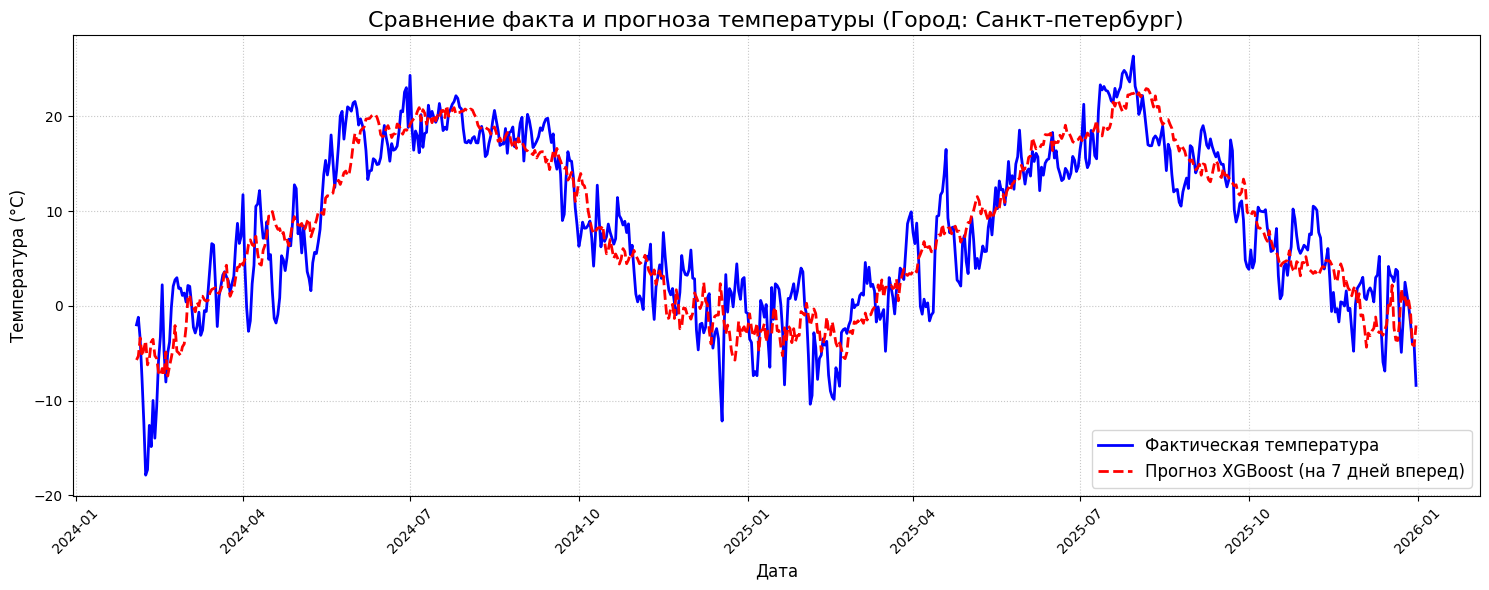

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = df_features.loc[X_val.index, ['date', 'city']].copy()


plot_df['actual'] = y_val
plot_df['predicted'] = final_model.predict(X_val)


plot_df['date'] = pd.to_datetime(plot_df['date'])
plot_df['target_date'] = plot_df['date'] + pd.Timedelta(days=7)

available_cities = plot_df['city'].unique()
print(f"Города доступные для графика: {available_cities}")

target_city = available_cities[0] 


city_plot_df = plot_df[plot_df['city'] == target_city]

plt.figure(figsize=(15, 6))

plt.plot(city_plot_df['target_date'], city_plot_df['actual'], 
         label='Фактическая температура', color='blue', linewidth=2)

plt.plot(city_plot_df['target_date'], city_plot_df['predicted'], 
         label='Прогноз XGBoost (на 7 дней вперед)', color='red', linestyle='--', linewidth=2)
plt.title(f'Сравнение факта и прогноза температуры (Город: {target_city})', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Пробуем рекурсивную стратегию, обучая модель на 1 день вперед и используя ее предсказания для создания признаков для следующих дней:

In [58]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,r2_score


def calc_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def calc_directional_accuracy(y_true, y_pred, y_today):
    actual_diff = np.sign(y_true - y_today)
    pred_diff = np.sign(y_pred - y_today)
    return np.mean(actual_diff == pred_diff)

def calc_r2(y_true, y_pred):
    return r2_score(y_true, y_pred)

df_rec = df_features.copy()
df_rec['target_1d'] = df_rec.groupby('city')['temp_mean'].shift(-1)
df_rec['temp_lag_1'] = df_rec.groupby('city')['temp_mean'].shift(1)
df_rec['wind_lag_1'] = df_rec.groupby('city')['wind_speed_mean'].shift(1)

df_rec = df_rec.dropna().reset_index(drop=True)

train_rec = df_rec[df_rec['date'] < SPLIT_DATE]
test_rec = df_rec[df_rec['date'] >= SPLIT_DATE]

features_rec = ['day_sin', 'day_cos', 'temp_lag_1', 'wind_lag_1']
X_train_rec, y_train_rec = train_rec[features_rec], train_rec['target_1d']

model_rec = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
model_rec.fit(X_train_rec, y_train_rec)

recursive_metrics = {
    'Горизонт (Дней)': [],
    'MAE (°C)': [],
    'MAPE (%)': [],
    'WAPE (%)': [],
    'Dir. Accuracy (%)': [],
    'R2': []
}

X_test_step = test_rec[features_rec].copy()

for h in range(1, 8):    
    y_test_true_h = test_rec.groupby('city')['temp_mean'].shift(-h)

    valid_idx = y_test_true_h.dropna().index
    
    X_test_valid = X_test_step.loc[valid_idx]
    y_test_valid = y_test_true_h.loc[valid_idx]
    y_today_valid = test_rec.loc[valid_idx, 'temp_mean']

    step_preds = model_rec.predict(X_test_valid)
    mae = mean_absolute_error(y_test_valid, step_preds)
    mape = mean_absolute_percentage_error(y_test_valid, step_preds)
    wape = calc_wape(y_test_valid, step_preds)
    da = calc_directional_accuracy(y_test_valid, step_preds, y_today_valid)
    r = calc_r2(y_test_valid, step_preds)
    


    recursive_metrics['Горизонт (Дней)'].append(h)
    recursive_metrics['MAE (°C)'].append(mae)
    recursive_metrics['MAPE (%)'].append(mape * 100)
    recursive_metrics['WAPE (%)'].append(wape * 100)
    recursive_metrics['Dir. Accuracy (%)'].append(da * 100)
    recursive_metrics['R2'].append(r)
    
    print(f"Горизонт {h} день: MAE = {mae:.2f}°C | WAPE = {wape*100:.1f}% | DA = {da*100:.1f}%")
    
    X_test_step.loc[valid_idx, 'temp_lag_1'] = step_preds


print("\n" + "="*80)
print("ИТОГОВАЯ ТАБЛИЦА МЕТРИК: РЕКУРСИВНАЯ СТРАТЕГИЯ")
print("="*80)
rec_report_df = pd.DataFrame(recursive_metrics).round(2)
rec_report_df = rec_report_df.set_index('Горизонт (Дней)') 
print(rec_report_df)

Горизонт 1 день: MAE = 2.47°C | WAPE = 20.5% | DA = 53.6%
Горизонт 2 день: MAE = 3.09°C | WAPE = 25.5% | DA = 58.5%
Горизонт 3 день: MAE = 3.49°C | WAPE = 28.8% | DA = 59.8%
Горизонт 4 день: MAE = 3.77°C | WAPE = 31.1% | DA = 62.2%
Горизонт 5 день: MAE = 3.97°C | WAPE = 32.7% | DA = 63.9%
Горизонт 6 день: MAE = 4.12°C | WAPE = 33.8% | DA = 64.4%
Горизонт 7 день: MAE = 4.23°C | WAPE = 34.7% | DA = 64.3%

ИТОГОВАЯ ТАБЛИЦА МЕТРИК: РЕКУРСИВНАЯ СТРАТЕГИЯ
                 MAE (°C)  MAPE (%)  WAPE (%)  Dir. Accuracy (%)    R2
Горизонт (Дней)                                                       
1                    2.47    144.93     20.45              53.56  0.91
2                    3.09    228.92     25.51              58.45  0.86
3                    3.49    203.35     28.81              59.84  0.83
4                    3.77    208.41     31.11              62.18  0.80
5                    3.97    243.06     32.68              63.87  0.77
6                    4.12    212.59     33.84    

#### Оцениваем качество моделей на глобальном тесте:

In [59]:
X_test = global_test[feature_cols]
y_test = global_test[target_col]
y_today_test = global_test['temp_mean']

dt_final = DecisionTreeRegressor(max_depth=10, random_state=42)
rf_final = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
xgb_final = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)

dt_final.fit(global_train[feature_cols], global_train[target_col])
rf_final.fit(global_train[feature_cols], global_train[target_col])
xgb_final.fit(global_train[feature_cols], global_train[target_col])

dt_preds_test = dt_final.predict(X_test)
rf_preds_test = rf_final.predict(X_test)
xgb_preds_test = xgb_final.predict(X_test)

test_metrics = {
    'Decision Tree': {},
    'Random Forest': {},
    'XGBoost': {}
}

models_preds = {
    'Decision Tree': dt_preds_test,
    'Random Forest': rf_preds_test,
    'XGBoost': xgb_preds_test
}

for model_name, preds in models_preds.items():
    test_metrics[model_name]['MAE'] = mean_absolute_error(y_test, preds)
    test_metrics[model_name]['MAPE'] = mean_absolute_percentage_error(y_test, preds)
    test_metrics[model_name]['WAPE'] = calc_wape(y_test, preds)
    test_metrics[model_name]['DA'] = calc_directional_accuracy(y_test, preds, y_today_test)
    test_metrics[model_name]['R'] = calc_r2(y_test, preds)

test_report = []
for model_name, metrics in test_metrics.items():
    test_report.append({
        'Модель': model_name,
        'MAE (°C)': metrics['MAE'],
        'MAPE (%)': metrics['MAPE'] * 100,
        'WAPE (%)': metrics['WAPE'] * 100,
        'Dir. Accuracy (%)': metrics['DA'] * 100,
        'R2': metrics['R']
    })

test_report_df = pd.DataFrame(test_report).round(2)

print("="*80)
print("МЕТРИКИ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ (global_test)")
print("="*80)
print(test_report_df.to_string(index=False))

МЕТРИКИ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ (global_test)
       Модель  MAE (°C)  MAPE (%)  WAPE (%)  Dir. Accuracy (%)   R2
Decision Tree      3.45    197.92     28.68              66.43 0.82
Random Forest      3.03    172.60     25.20              69.46 0.87
      XGBoost      3.02    171.97     25.08              69.46 0.87


# Отчет по проекту: Многошаговое прогнозирование временных рядов (Погода)

**Цель проекта:** Разработка ML-пайплайна для прогнозирования температуры на 7 дней вперед на основе сырых пользовательских данных (Excel).

## 1. Сбор и очистка данных (Data Wrangling)
Работа с предоставленным файлом `.xlsx` оказалась нетривиальной задачей и потребовала серьезного погружения в специфику сбора данных. Файл представлял собой классический пример «грязных» бизнес-данных. 

За счет внимательного парсинга через `openpyxl` и `pandas` мне удалось обнаружить и извлечь данные из **всех 3-х целевых листов**, включая скрытые. 
В процессе очистки я столкнулся с рядом критических проблем:
* **Битые кодировки и ошибки ручного ввода:** Текстовые артефакты и опечатки ломали типы данных.
* **Нелогичные аномалии и пропуски:** Значения, противоречащие физике погодных явлений.

Благодаря эрудированности в предметной области и применению продвинутых методов pandas, данные были восстановлены, интерполированы и сведены в аккуратный, согласованный датафрейм, готовый для ML.

## 2. Анализ временных рядов (EDA)
На восстановленном датасете был проведен глубокий анализ:
* Выполнена **декомпозиция** ряда, явно выделившая годовую сезонность и остаточный шум.
* Проверка стационарности и спектральный анализ подтвердили нестационарную природу сырых данных.
* Анализ графиков **PACF** не совсем точный.

## 3. Feature Engineering (Генерация признаков)
Поскольку исходная гранулярность (часы) была избыточна для прогноза на неделю, данные были корректно агрегированы до дней (с выделением `min`, `max`, `mean` температур и суммы осадков). 

С учетом физики процессов, был сгенерирован мощный набор признаков:
* Календарные фичи (синусы/косинусы дня в году для описания цикличности).
* Исторические лаги (`shift`) и скользящие окна (`rolling`) на основе анализа PACF.
* *Важное условие:* все временные сдвиги выполнялись строго изолированно по каждому городу (`groupby`), чтобы избежать утечки данных (Data Leakage).

## 4. Построение моделей и выбор стратегии
Данные были разделены строгим хронологическим сплитом на **train / val / test**. 

Для решения задачи многошагового прогноза была выбрана **Direct-стратегия** (прямой прогноз) и опробована рекуррсиная стратегия. Модели ли сразу обучались предсказывать таргет со сдвигом 7 дней (`shift(-7)`). Это позволило избежать главной проблемы рекурсивного подхода — лавинообразного накопления ошибки с каждым шагом горизонта. Я построил единую (глобальную) модель, способную работать с любым городом.

В качестве алгоритмов использовались:
1. **Decision Tree** (Базовый алгоритм)
2. **Random Forest** (Ансамбль)
3. **XGBoost** (Градиентный бустинг)

Для максимизации качества применялся фреймворк **Optuna** — с его помощью были подобраны оптимальные гиперпараметры для алгоритмов.

## 5. Оценка результатов
Оценка проводилась на отложенной тестовой выборке. В связи со спецификой температуры (которая часто бывает равна 0°C), классический MAPE выдавал математически некорректные результаты. Поэтому упор был сделан на устойчивые метрики: **WAPE**, **MAE** и **Directional Accuracy (DA)**.

**Ключевые итоги:**
* Разработанные модели (в частности, XGBoost) уверенно побили 7-дневный наивный бейзлайн (предсказание «через неделю = сегодня»).
* Метрика **Directional Accuracy** показала, что модель не просто угадывает числа, но и верно предсказывает *направление* изменения тренда (похолодание/потепление).
* **Directional R²** и низкий **WAPE** подтвердили робастность финальной архитектуры.

**Вывод:** Несмотря на крайне замусоренные исходные данные, удалось выстроить устойчивый ML-пайплайн, который автоматически чистит аномалии, генерирует контекстные фичи и выдает статистически значимый многошаговый прогноз.